# Integration of Expression analysis all SHMss events K12345678B

In [345]:
# Load packages
options(warn = -1)
library("IRdisplay")
library(tidyverse)
library(Seurat)
library(ggh4x)
library(data.table)
library(ggpubr)
library(rstatix)
library("ggbreak")
library(RSSL)
suppressPackageStartupMessages( library( DESeq2 ) )

In [46]:
suppressMessages(source("code/functions.R"))

## Load data

### Load and bind input data (all sequences) for K123B and K45678B

In [3]:
# df_seq1 <- Sys.glob("input/output_shm_v4up/FL/consensus/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
#       filter(ref_vdj_coverage == '1.0')
#   })

In [4]:
# df_seq2 <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv")  %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
#       filter(ref_vdj_coverage == "1.0")
#   })

In [5]:
# df_seq <- df_seq1 %>% bind_rows(df_seq2)

In [6]:
# write.csv(df_seq, "output/UMI_consensus_K12345678.csv",row.names = FALSE)

In [ ]:
df_seq <- read.csv("output/UMI_consensus_K12345678.csv")
head(df_seq)

### Load doublets

In [9]:
# #read doublet table
# dou_k123 <- read.csv("output/doublet_in_K123_v1.csv") 

In [10]:
# #read doublet table
# dou_k45678 <- read.csv("output/doublet_in_K45678.csv") %>% select(-X,-SHMa_pos)

In [11]:
# doublet <- dou_k123 %>% bind_rows(dou_k45678)

In [12]:
#write.csv(doublet, "output/doublet_K12345678.csv",row.names = FALSE)

In [4]:
doublet <- read.csv("output/doublet_K12345678.csv")

### Load all SHMss events detected (positive + false positive)

In [14]:
# df1 <- Sys.glob("input/shm_incl_po_subrg.20210912/FL/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
#   })

In [15]:
# # load data
# df2 <- Sys.glob("input/output_shm_20220819/shm_incl_po/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "ccicccilciicc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
#   })

In [16]:
# df <- df1 %>% bind_rows(df2)

In [17]:
# write.csv(df, "output/shm_K12345678.csv",row.names = FALSE)

In [3]:
df <- read.csv("output/shm_K12345678.csv")

ERROR: Error in read.table(file = file, header = header, sep = sep, quote = quote, : no lines available in input


### Load df with filtered SHMss events (trully positive)

In [19]:
# df_summary1 <- read.csv("output/df_summary_K123_v1.csv")
# str(df_summary1)

In [20]:
# df_summary2 <- read.csv("output/df_summary_K45678_v5.csv")
# str(df_summary2)

In [21]:
# df_summary <- df_summary1 %>% bind_rows(df_summary2)

In [22]:
#write.csv(df_summary, "output/df_summary_K12345678.csv",row.names = FALSE)

In [31]:
df_summary <- read.csv("output/df_summary_K12345678_v3.csv")

### Load expression data (merged and integrated)

### Merge 8 experiments
We used seurat object with SCT transformation

In [24]:
# ### read first three objects 
# K1B <- readRDS("output/K1B_SCT.rds")
# K2B <- readRDS("output/K2B_SCT.rds")
# K3B <- readRDS("output/K3B_SCT.rds")

In [19]:
# K4B <- readRDS("output/K4B_SCT.rds")
# K5B <- readRDS("output/K5B_SCT.rds")

#new merge 2025
# K6B <- readRDS("output/K6B_SCT.rds")
# K7B <- readRDS("output/K7B_SCT.rds")
# K8B <- readRDS("output/K8B_SCT.rds")

In [21]:
# # combined the 8 experiments
# FL_merge <- merge(K6B, y = c(K7B, K8B), add.cell.ids = c("K6B","K7B", "K8B"), project = "FL")
# FL_merge

An object of class Seurat 
38663 features across 45004 samples within 2 assays 
Active assay: SCT (18615 features, 0 variable features)
 1 other assay present: RNA

In [22]:
# #save merge object
# saveRDS(FL_merge, "output/K678_SCT_merge.rds")

### Integrate 8 dataset and remove batch effect

**Tips for integrating large datasets**
https://satijalab.org/seurat/articles/integration_large_datasets.html

- For very large datasets, the standard integration workflow can sometimes be prohibitively computationally expensive. In this workflow, we employ two options that can improve efficiency and runtimes:

1. Reciprocal PCA (RPCA)
2. Reference-based integration (I did not do this one)

- This alternative workflow consists of the following steps:

1. Create a list of Seurat objects to integrate
2. Perform normalization, feature selection, and scaling separately for each dataset
3. Run PCA on each object in the list
4. Integrate datasets, and proceed with joint analysis

In [28]:
# # ### read first three objects (without SCT transformation)
# K1B <- readRDS("output/K1B.rds")
# K2B <- readRDS("output/K2B.rds")
# K3B <- readRDS("output/K3B.rds")

In [29]:
# ### read objects (without SCT transformation)
# K4B <- readRDS("output/K4B.rds")
# K5B <- readRDS("output/K5B.rds")
# K6B <- readRDS("output/K6B.rds")
# K7B <- readRDS("output/K7B.rds")
# K8B <- readRDS("output/K8B.rds")

In [30]:
# ### read objects (without SCT transformation)
# Q1 <- readRDS("output/Q1.rds")
# Q2 <- readRDS("output/Q2.rds")

In [31]:
# # merge in a list
# l <-
#   list(K1B, K2B, K3B, K4B, K5B, K6B, K7B, K8B, Q1, Q2)

**first perform standard normalization and variable feature selection** We use seurat object without SCT transformation

In [32]:
# l <- lapply(X = l, FUN = function(x) {
#     x <- NormalizeData(x, verbose = FALSE)
#     x <- FindVariableFeatures(x, verbose = FALSE)
# })

**Next, select features for downstream integration, and run PCA on each object in the list, which is required for running the alternative reciprocal PCA workflow**

In [33]:
# features <-   SelectIntegrationFeatures( object.list = l, nfeatures = 3500 ) %>% 
#     as.data.frame() %>% 
#     dplyr::rename( geneName = "." ) %>% 
#     filter( !geneName %like% "^RPL",
#             !geneName %like% "^RPS",
#             !geneName %like% "^IG[HKL][LVMCG]",
#             !geneName %like% "^MT-" ) %>% 
#     slice_head( n = 3000 ) %>% 
#   pull( geneName )
# l <- lapply(X = l, FUN = function(x) {
#     x <- ScaleData(x, features = features, verbose = FALSE)
#     x <- RunPCA(x, features = features, verbose = FALSE)
# })

**The main efficiency improvements are gained in FindIntegrationAnchors(). First, we use reciprocal PCA (RPCA) instead of CCA, to identify an effective space in which to find anchors.
When determining anchors between any two datasets using reciprocal PCA, we project each dataset into the others PCA space and constrain the anchors by the same mutual neighborhood requirement. All downstream integration steps remain the same and we are able to ‘correct’ (or harmonize) the datasets.**

In [34]:
# anchors <- FindIntegrationAnchors(object.list = l, reduction = "rpca", #all pairwise anchors are found
#     dims = 1:50)

Computing 2000 integration features

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1308 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1353 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1106 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1120 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 744 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 977 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 938 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 749 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1044 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1707 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 954 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 932 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 819 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1117 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1129 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1090 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 780 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 928 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1180 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1416 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1265 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 817 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 858 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 764 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 805 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1004 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 812 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1039 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 396 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 394 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 349 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 343 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 325 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 356 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 301 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 312 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 384 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 351 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 356 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 354 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 335 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 309 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 306 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 271 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 756 anchors

**Integrate data and save data**

In [35]:
#FL_CLL.integrated <- IntegrateData(anchorset = anchors, dims = 1:50)

Merging dataset 4 into 5

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 1 into 3

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 2 into 3 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 7 into 5 4

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 6 into 5 4 7

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 9 into 10

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 3 1 2 into 5 4 7 6

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 8 into 5 4 7 6 3 1 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 10 9 into 5 4 7 6 3 1 2 8

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

In [36]:
# FL_CLL.integrated <- ScaleData(FL_CLL.integrated, verbose = FALSE)
# FL_CLL.integrated <- RunPCA(FL_CLL.integrated, verbose = FALSE)
# FL_CLL.integrated <- RunUMAP(FL_CLL.integrated, dims = 1:50)

15:06:04 UMAP embedding parameters a = 0.9922 b = 1.112

15:06:04 Read 111562 rows and found 50 numeric columns

15:06:04 Using Annoy for neighbor search, n_neighbors = 30

15:06:04 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:06:23 Writing NN index file to temp file /var/folders/_y/9gg2ckqx641_1cl14gn22tk80000gn/T//RtmpW4gXCI/file37d53f399aa2

15:06:23 Searching Annoy index using 1 thread, search_k = 3000

15:07:11 Annoy recall = 100%

15:07:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:07:16 Initializing from normalized Laplacian + noise (using irlba)

15:07:24 Commencing optimization for 200 epochs, with 5498544 positive edges

15:08:28 Optimization finished


In [37]:
# FL_CLL.integrated <- FindNeighbors(FL_CLL.integrated, dims = 1:10)
# FL_CLL.integrated <- FindClusters(FL_CLL.integrated, resolution = 0.3)

Computing nearest neighbor graph

Computing SNN

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 111562
Number of edges: 2839128

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9027
Number of communities: 12
Elapsed time: 42 seconds

In [38]:
# #save integrated object
# saveRDS(FL_CLL.integrated, "output/FL_CLL_integrated.rds")

### Filter no cll cells

In [39]:
# # all cells
# length(colnames(FL_CLL.integrated))

In [40]:
# # Remove cells from Seurat object (MBL and donor)
# FL_CLL.integrated_clean <- FL_CLL.integrated[,!colnames(FL_CLL.integrated) %in% no_cll_cellbarcode]

In [41]:
# # cell after filter no cll or fl cells
# length(colnames(FL_CLL.integrated_clean))

In [42]:
# FL_CLL.integrated_clean <- ScaleData(FL_CLL.integrated_clean, verbose = FALSE)
# FL_CLL.integrated_clean <- RunPCA(FL_CLL.integrated_clean, verbose = FALSE)
# FL_CLL.integrated_clean <- RunUMAP(FL_CLL.integrated_clean, dims = 1:50)

12:01:10 UMAP embedding parameters a = 0.9922 b = 1.112

12:01:10 Read 103555 rows and found 50 numeric columns

12:01:10 Using Annoy for neighbor search, n_neighbors = 30

12:01:10 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:01:46 Writing NN index file to temp file /var/folders/_y/9gg2ckqx641_1cl14gn22tk80000gn/T//Rtmpf0Q09P/file3d6569b8159

12:01:46 Searching Annoy index using 1 thread, search_k = 3000

12:03:02 Annoy recall = 100%

12:03:02 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:03:09 Initializing from normalized Laplacian + noise (using irlba)

12:03:26 Commencing optimization for 200 epochs, with 5086646 positive edges

12:05:20 Optimization finished

In [43]:
# # cell after filter no cll or fl cells
# length(colnames(FL_CLL.integrated_clean))

In [44]:
# # Generate cluster in without no cll cells or FL
# FL_CLL.integrated_clean <- FindNeighbors(FL_CLL.integrated_clean, dims = 1:10)
# FL_CLL.integrated_clean <- FindClusters(FL_CLL.integrated_clean, resolution = 0.3)

In [45]:
# # cell after filter no cll or fl cells
# length(colnames(FL_CLL.integrated_clean))

In [46]:
# #save integrated object
# saveRDS(FL_CLL.integrated_clean, "output/FL_CLL_integrated_clean.rds")

### List of DNA repair genes

In [25]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [26]:
# number of genes analysed
length(genes_names$gene)

[1] 66

## **Analysis with normalize and scale data**

- 'FL.integrated@assays$RNA@data' : NormalizeData divides each feature in a cell with the total UMI counts for that cell, multiples the number by 10000, and then natural log + 1 transforms the counts, so you don't expect any negative values. 
- ScaleData then centers and scales those counts.

In [2]:
FL_CLL.integrated_clean <- readRDS("output/FL_CLL_integrated_clean.rds")

### **Pre-processing df for UMAP analysis**

In [15]:
# obtain cell scSHM positive to include to metadata
df_sumary_cb <- df_summary %>% mutate(case= str_extract(subject, "^\\w+\\_\\w+")) %>%
  mutate(cellbarcode = paste0(cell,"-1_",gsub("K(\\d+)B.*", "\\1", subject))) %>%
  mutate(sample =str_extract(subject, "(?<=\\_)[^\\-]+")) %>%
  select(cellbarcode, case, sample) %>% unique()

head(df_sumary_cb)

,cellbarcode,case,sample
,<chr>,<chr>,<chr>
1,AGCTTGACAATGGACG-1_1,K1B_S10000,S10000
3,CTAGCCTCAATCACAC-1_1,K1B_S10000,S10000
4,CGAGCACAGGTTCCTA-1_1,K1B_S10000,S10000
5,ATCATGGGTGGTCTCG-1_1,K1B_S144,S144
6,TCTTTCCGTCTAGTCA-1_1,K1B_S144,S144
7,ACGCCAGAGGCATTGG-1_1,K1B_S144,S144


In [16]:
#extract metadata to obtain df with all cells
sample_metadata <- FL_CLL.integrated_clean@meta.data %>% rownames_to_column("cellbarcode") %>%
              mutate(scSHM= ifelse(cellbarcode %in% df_sumary_cb$cellbarcode, TRUE, FALSE)) %>%
              select(cellbarcode, scSHM) %>% column_to_rownames(var="cellbarcode")

In [17]:
# Add metadata to Seurat object
FL_CLL.integrated_clean <- AddMetaData(object = FL_CLL.integrated_clean, metadata = sample_metadata)

In [18]:
# exctract information of subject for K123B

# read cell subject assignment (20552 cells)
cellSubject <-
    readr::read_csv( "~/repositories/FL_10X_2/182_SCSM_subjects/outs/FL_10X.SCSM_fit.ss.tsv" ) %>% 
    dplyr::rename( cell = c,
                   subject = calledS ) %>% 
  filter( !p %like% "n",
          !subject %in% c( "doublet", "SID11", "SID12", "unassigned" ) ) %>% 
  # fix difference cell
  mutate( cellSCSM = cell,
          cell = paste0( substr( cell, 5, 100 ), "_", substr( cell, 2, 2 ) ) ) %>% 
  dplyr::rename( source = p )  %>%
  mutate(cell= gsub('.{4}$', '', cell)) %>%
  mutate(cellbarcode = paste0(cell,"-1_",gsub("K(\\d+)B.*", "\\1", source)))
  cellSubject[ which (cellSubject$subject == "SID14" ), "subject" ] <-
    "S15629"

Rows: 36708 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): p, c, calledS, status
lgl (2): isSinglet, isDoublet

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
# data for subjects K123B 
cellSubject_k123B <- cellSubject %>% select(source,subject,cellbarcode) #%>% rename(e=source)

In [9]:
no_cll <- c("S10007_Donor","S5001_Donor", "S5048_Donor", "S5530_Donor", "S7580_Donor", "S9121_MBL", "S9534_MBL")

In [ ]:
#add data for CLL subjects
cell_subject_cll <- read.csv("output/id_cell.csv") %>% select(source, subject,cellbarcode) %>%
                    mutate(cellbarcode = case_when(source == "Q1" ~ paste0(substring(cellbarcode, 1, nchar(cellbarcode)-1), "9"), 
                                                    source == "Q2" ~ paste0(substring(cellbarcode, 1, nchar(cellbarcode)-1), "10"),
                                                    TRUE ~ cellbarcode))

# join subject information from K123B and CLL
cell_subject <- bind_rows(cellSubject_k123B,cell_subject_cll) %>% filter(!subject %in% no_cll)
head(cell_subject)

In [ ]:
# Extract the t-SNE coordinates from the integrated Seurat object
tsne_coordinates <- FL_CLL.integrated_clean@reductions$umap@cell.embeddings

# Create a data frame with the t-SNE coordinates and cluster information
umap_df <- data.frame(x = tsne_coordinates[, 1], y = tsne_coordinates[, 2],
                      cluster = FL_CLL.integrated_clean@active.ident,
                      source = FL_CLL.integrated_clean@meta.data$orig.ident,
                      annotation = FL_CLL.integrated_clean@meta.data$scSHM)
umap_df <- umap_df %>% rownames_to_column("cellbarcode") %>% left_join(cell_subject, by=c("cellbarcode","source")) %>%
    mutate(cluster= factor(as.integer(as.character(cluster)) + 1),
    subject = case_when(
    source %in% c("K1B", "K2B", "K3B", "Q1", "Q2") ~ subject,
    source == "K4B" ~ "S8934",
    source == "K5B" ~ "S8934",
    source == "K6B" ~ "S13530",
    source == "K7B" ~ "S10000",
    source == "K8B" ~ "S13553",
    TRUE ~ "other string"), 
    diagnosis = case_when(source %like% "K" ~ "FL",
                         source %like% "Q" ~ "CLL",
                         TRUE ~ NA)) %>%
    filter(!is.na(subject)) %>%
    mutate(subject = case_when(
    diagnosis == "FL" ~ paste0(subject,"_",diagnosis),
    diagnosis == "CLL" ~ subject,
    TRUE ~ NA))  # we lose ~12.000 cells not defined
  

head(umap_df)

In [ ]:
# Change levels subject
umap_df$subject <- factor(umap_df$subject, levels = c("S144_FL","S8382_FL","S8934_FL","S10000_FL","S10971_FL","S11770_FL", "S12118_FL", "S12282_FL", "S12390_FL", "S12500_FL", "S13530_FL",
  "S13553_FL", "S15629_FL", "S356_CLL", "S4725_CLL", "S5714_CLL", "S7482_CLL", "S9856_CLL") )

In [ ]:
# Change levels diagnosis
umap_df$diagnosis <- factor(umap_df$diagnosis, levels = c("FL","CLL"))

In [ ]:
umap_df %>% pull(subject) %>% table()

In [ ]:
no_cll_cellbarcode <- cell_subject %>% filter(subject %in% no_cll) %>% pull(cellbarcode)
#write.csv(no_cll_cellbarcode, "output/no_cll_cellbarcode.csv")

In [ ]:
#write.csv(umap_df, "output/umap_df.csv",row.names = FALSE)

In [5]:
umap_df <- read.csv("output/umap_df.csv")

In [6]:
head(umap_df)

,cellbarcode,x,y,cluster,source,annotation,subject,diagnosis
,<chr>,<dbl>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>
1,AAACCTGAGATCACGG-1_1,-3.226022,-5.7686452,3,K1B,FALSE,S10971_FL,FL
2,AAACCTGAGCCAGTTT-1_1,-4.736977,-3.3012649,5,K1B,FALSE,S144_FL,FL
3,AAACCTGAGGCATGTG-1_1,1.728376,-2.4358713,1,K1B,FALSE,S144_FL,FL
4,AAACCTGAGTGTTTGC-1_1,-4.904546,-2.9531554,5,K1B,FALSE,S10000_FL,FL
5,AAACCTGCAACTGCTA-1_1,2.092530,0.7526002,1,K1B,FALSE,S10971_FL,FL
6,AAACCTGCACCACCAG-1_1,5.590599,-3.2310015,7,K1B,FALSE,S8934_FL,FL


### **UMAP ploting by diagnosis**

In [7]:
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#8c6bb1", "#d01c8b", "#e7298a", "#66a61e", "#ffeda0")
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
                "#D55E00", "#CC79A7", "#4169E1", "#FFAABB", "#DDCC77",
                "#22AA99", "#99DDFF", "#AA4499","#ffeda0",
           "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A")
cluster_colors <- c("#a6cee3","#1f78b4" ,"#b2df8a" ,"#33a02c", "#fb9a99", "#e31a1c" ,"#fdbf6f" ,"#ff7f00" ,"#cab2d6", "#6a3d9a")
cluster_colors <- c("#ffa832", "#938abe", "#00A693", "#FCC900", "#579CDE",
                "#E85356", "#9F4B80", "#2691E1", "#FFB4C4", "#B8A81B")

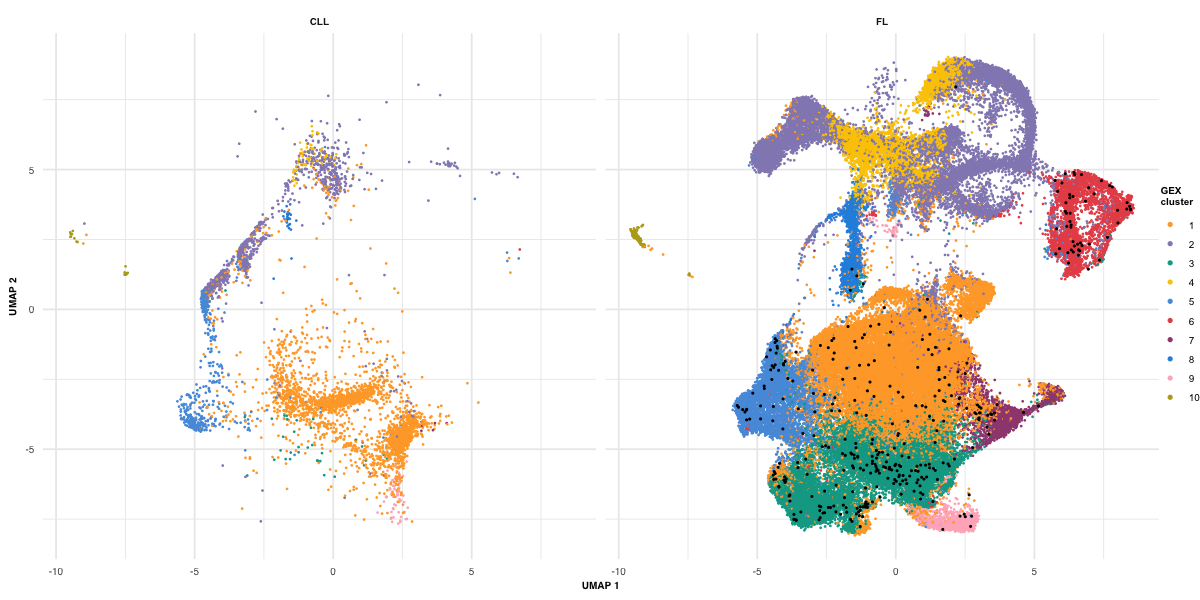

In [10]:
options(repr.plot.width=10, repr.plot.height=5)

# plot umap + clusters
umap_plot <- ggplot( umap_df %>% filter(!subject %in% no_cll), aes( x, y,color = factor(cluster ) )) +
  geom_point(size = 0.1, alpha = 1) +
  geom_point( data = umap_df %>%
                filter( annotation == TRUE ),
              aes( x, y ), color = "black",size = 0.2) +
 scale_color_manual(values = cluster_colors,name = "GEX \ncluster") +
 theme_minimal() +
 labs(x = "UMAP 1", y = "UMAP 2") +
  theme(
    legend.title = element_text(size = 6, face = "bold"),
    legend.text = element_text(size = 6),
    legend.key.size = unit(0.8, "lines"),
    axis.title = element_text(size = 6, face = "bold", family = "sans"),
    axis.text = element_text(size = 6, family = "sans"),
    plot.title = element_text(size = 8, face = "bold", family = "sans"),
    legend.key = element_rect(color = NA),
    strip.text = element_text(size=6,face = "bold"),
    legend.margin=margin(0,0,0,0),
    legend.box.margin=margin(-10,-5.5,-10,-10)
  )+
  guides(color = guide_legend(override.aes = list(size=0.8))) +
  facet_wrap(~diagnosis, nrow = 1,ncol=2)

umap_plot

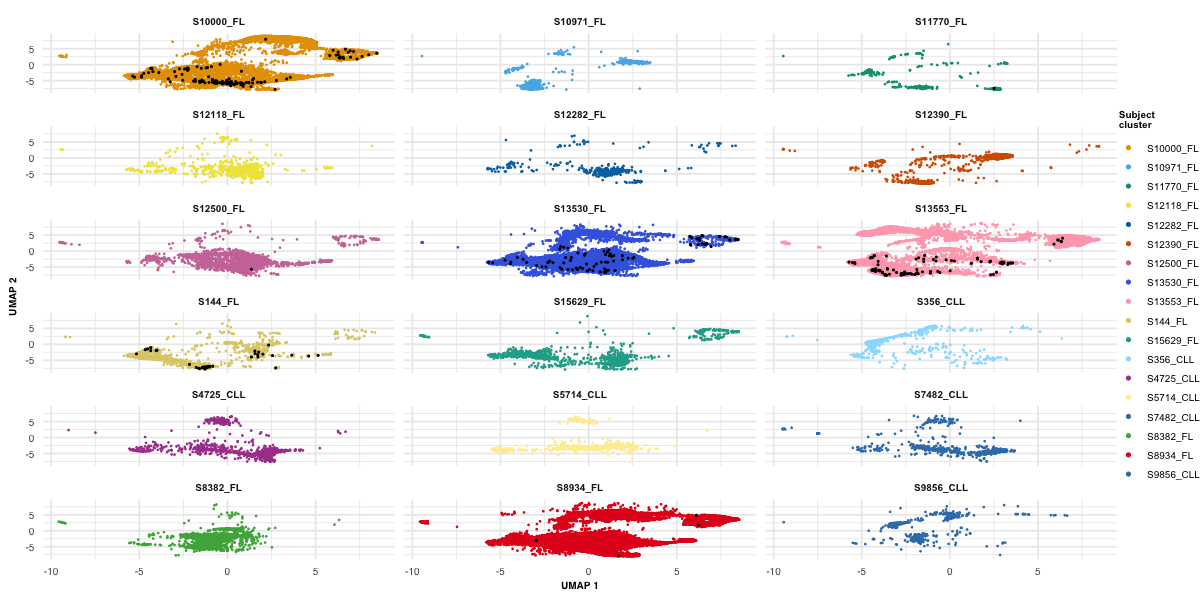

In [15]:
options(repr.plot.width=10, repr.plot.height=5)

# plot umap + clusters
umap_plot <- ggplot( umap_df %>% filter(!subject %in% no_cll), aes( x, y,color = factor(subject ) )) +
  geom_point(size = 0.1, alpha = 1) +
  geom_point( data = umap_df %>%
                filter( annotation == TRUE ),
              aes( x, y ), color = "black",size = 0.2) +
 scale_color_manual(values = colors,name = "Subject \ncluster") +
 theme_minimal() +
 labs(x = "UMAP 1", y = "UMAP 2") +
  theme(
    legend.title = element_text(size = 6, face = "bold"),
    legend.text = element_text(size = 6),
    legend.key.size = unit(0.8, "lines"),
    axis.title = element_text(size = 6, face = "bold", family = "sans"),
    axis.text = element_text(size = 6, family = "sans"),
    plot.title = element_text(size = 8, face = "bold", family = "sans"),
    legend.key = element_rect(color = NA),
    strip.text = element_text(size=6,face = "bold"),
    legend.margin=margin(0,0,0,0),
    legend.box.margin=margin(-10,-5.5,-10,-10)
  )+
  guides(color = guide_legend(override.aes = list(size=0.8))) +
  facet_wrap(~subject, nrow = 6,ncol=3)

umap_plot

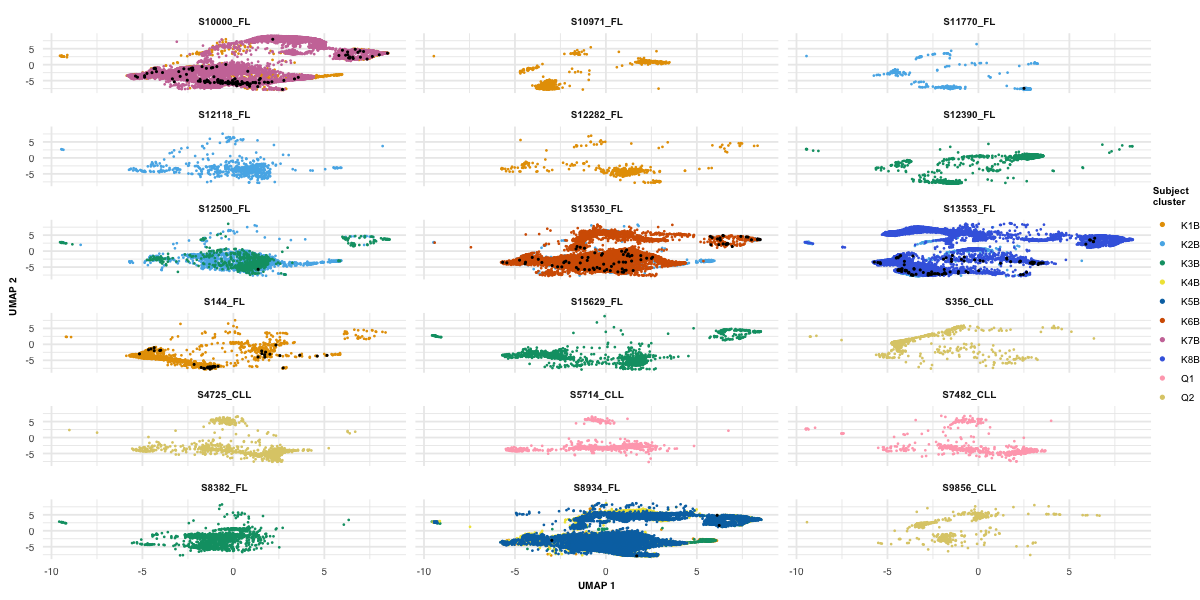

In [16]:
options(repr.plot.width=10, repr.plot.height=5)

# plot umap + clusters
umap_plot <- ggplot( umap_df %>% filter(!subject %in% no_cll), aes( x, y,color = factor(source) )) +
  geom_point(size = 0.1, alpha = 1) +
  geom_point( data = umap_df %>%
                filter( annotation == TRUE ),
              aes( x, y ), color = "black",size = 0.2) +
 scale_color_manual(values = colors,name = "Subject \ncluster") +
 theme_minimal() +
 labs(x = "UMAP 1", y = "UMAP 2") +
  theme(
    legend.title = element_text(size = 6, face = "bold"),
    legend.text = element_text(size = 6),
    legend.key.size = unit(0.8, "lines"),
    axis.title = element_text(size = 6, face = "bold", family = "sans"),
    axis.text = element_text(size = 6, family = "sans"),
    plot.title = element_text(size = 8, face = "bold", family = "sans"),
    legend.key = element_rect(color = NA),
    strip.text = element_text(size=6,face = "bold"),
    legend.margin=margin(0,0,0,0),
    legend.box.margin=margin(-10,-5.5,-10,-10)
  )+
  guides(color = guide_legend(override.aes = list(size=0.8))) +
  facet_wrap(~subject, nrow = 6,ncol=3)

umap_plot

In [182]:
#fig_save(umap_plot, filename = "figs_paper/UMAP_by_cluster", formats = c("pdf", "png"), width = 8.8, height = 5.33, units = "cm", dpi = 600)

### **Bar plot events by cluster**

In [150]:
event_by_cluster <-umap_df %>% filter(!subject %in% no_cll) %>% group_by(cluster) %>% count(annotation) %>% mutate(percentage=n*100/sum(n)) %>%
                   ungroup() %>%
                    complete(cluster, annotation, fill = list(n = 0, percentage=0)) # add missing data

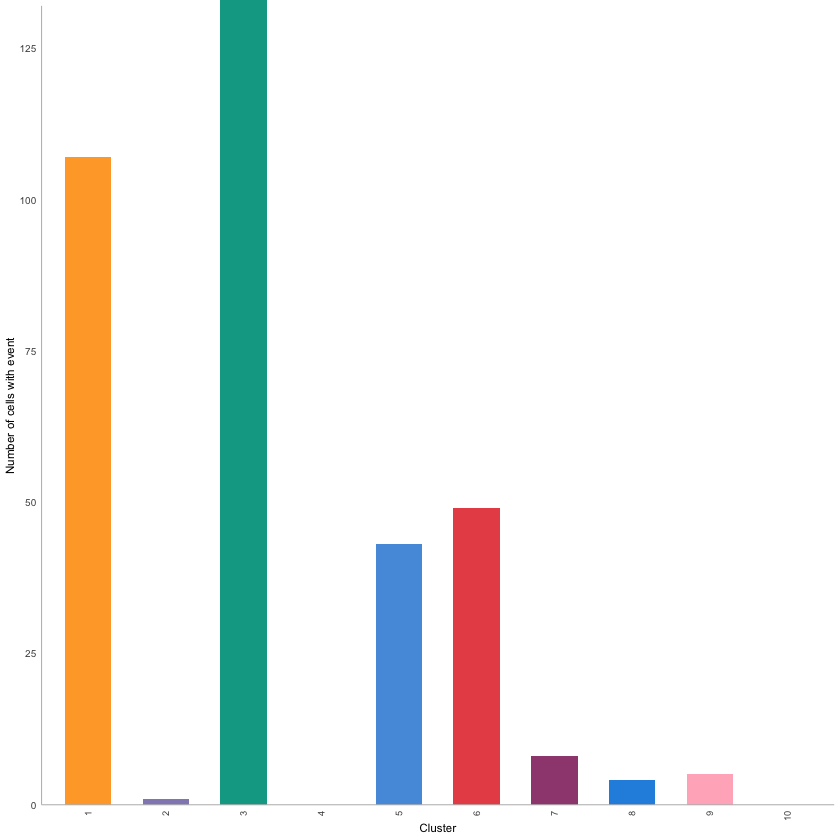

In [153]:
# create the plot
event_bar_plot <- ggplot(event_by_cluster %>% filter(annotation == TRUE), aes(x = factor(cluster), y = n, fill = factor(cluster))) +
  geom_bar(stat = "identity", width = 0.6) +
  scale_fill_manual(values = cluster_colors) +
  labs(x = "Cluster", y = "Number of cells with event") +
  theme_minimal(base_size = 7) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
        axis.text.y = element_text(size = 6),
        axis.title = element_text(size = 7),
        legend.position = "none",
        legend.title = element_blank(),
        legend.text = element_text(size = 8),
        plot.title = element_text(size = 10, face = "bold", hjust = 0.5),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color="grey", size = 0.3)
 #       panel.border = element_blank(),
 #       panel.background = element_blank()) 
        )+
  coord_cartesian(clip = "off", ylim = c(0, max(120, na.rm = TRUE) * 1.1)) +
  scale_y_continuous(expand = c(0, 0.02)) +
  guides(fill = guide_legend(ncol = 10))


event_bar_plot

In [184]:
fig_save(event_bar_plot, filename = "figs_paper/barplot_postive_cells_by_cluster", formats = c("pdf", "png"), width = 9.8, height = 4.32, units = "cm", dpi = 600)

### **UMAP ploting by subject**

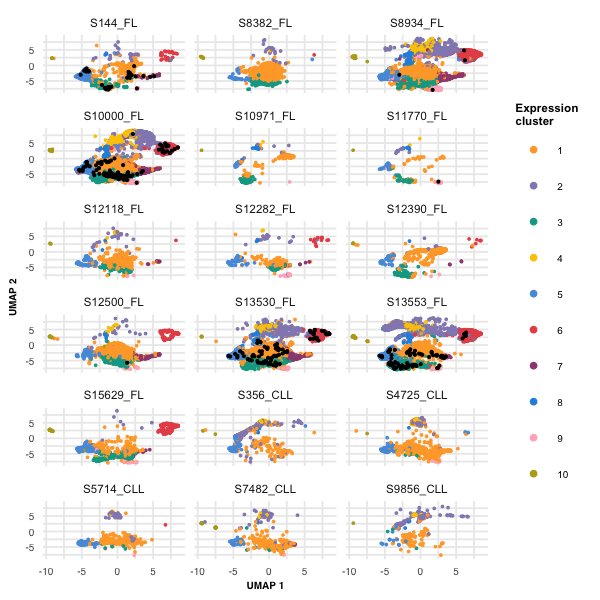

In [67]:
options(repr.plot.width=5, repr.plot.height=5)

# plot umap + clusters

# # define colors for clusters and annotations
# cluster_colors <- c("#E41A1C", "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A")
# annotation_color <- "black"
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#8c6bb1", "#d01c8b", "#e7298a", "#66a61e", "#ffeda0")
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
                "#D55E00", "#CC79A7", "#4169E1", "#FFAABB", "#DDCC77",
                "#22AA99", "#99DDFF", "#AA4499","#ffeda0",
           "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A")

umap_plot <- ggplot( umap_df %>% filter(!subject %in% no_cll), aes( x, y,color = cluster) ) +
  geom_point(size = 0.4, alpha = 1) +
  geom_point( data = umap_df %>%
                filter( annotation == TRUE ),
              aes( x, y ), color = "black",size = 0.5) +
 scale_color_manual(values = cluster_colors,name = "Expression \ncluster") +
 theme_minimal() +
 labs(x = "UMAP 1", y = "UMAP 2") +
  theme(
    legend.title = element_text(size = 7, face = "bold"),
    legend.text = element_text(size = 6),
    legend.key.size = unit(1.5, "lines"),
    axis.title = element_text(size = 6, face = "bold", family = "sans"),
    axis.text = element_text(size = 6, family = "sans"),
    plot.title = element_text(size = 7, face = "bold", family = "sans"),
    legend.key = element_rect(color = NA),
    panel.grid.major = element_line(size=0.5),
    panel.grid.minor = element_line(size=0.5),
    strip.text = element_text(size=7)
  )+
  guides(color = guide_legend(override.aes = list(size=1.5))) +
 facet_wrap(~subject, nrow = 6,ncol=3)

umap_plot

In [68]:
fig_save(umap_plot, filename = "figs_paper/UMAP_by_subject", formats = c("pdf", "png"), width = 12, height = 10, units = "cm", dpi = 320)

### **Bar plot cells by cluster**

In [126]:
no_cll <- c("S10007_Donor","S5001_Donor", "S5048_Donor", "S5530_Donor", "S7580_Donor", "S9121_MBL", "S9534_MBL")

In [127]:
diagnosis_by_cluster <-umap_df %>% filter(!subject %in% no_cll) %>% group_by(cluster) %>% count(diagnosis) %>% group_by(diagnosis) %>% mutate(percentage=n*100/sum(n)) %>%
                   ungroup() %>%
                    complete(cluster, diagnosis, fill = list(n = 0, percentage=0)) # add missing data

In [128]:
diagnosis_by_cluster

cluster,diagnosis,n,percentage
<int>,<chr>,<int>,<dbl>
1,CLL,2601,58.2400358
1,FL,30521,35.1592019
2,CLL,1079,24.1603224
2,FL,16600,19.1226615
3,CLL,40,0.8956561
3,FL,16030,18.4660400
4,CLL,69,1.5450067
4,FL,7564,8.7134826
5,CLL,572,12.8078818


In [129]:
cells_by_cluster <-umap_df %>% filter(!subject %in% no_cll) %>% group_by(cluster) %>% count(diagnosis) %>% ungroup() %>% mutate(percentage=n*100/sum(n)) %>%
                   ungroup() %>%
                    complete(cluster, diagnosis, fill = list(n = 0, percentage=0)) # add missing data

cells_by_cluster

cluster,diagnosis,n,percentage
<int>,<chr>,<int>,<dbl>
1,CLL,2601,2.849661459
1,FL,30521,33.438876350
2,CLL,1079,1.182154831
2,FL,16600,18.186997392
3,CLL,40,0.043824090
3,FL,16030,17.562504109
4,CLL,69,0.075596555
4,FL,7564,8.287135438
5,CLL,572,0.626684488


In [136]:
#colors_diagnosis <- c("#64a2ce","#cec564")
colors_diagnosis <- c("#e583a9","#82d0d2")

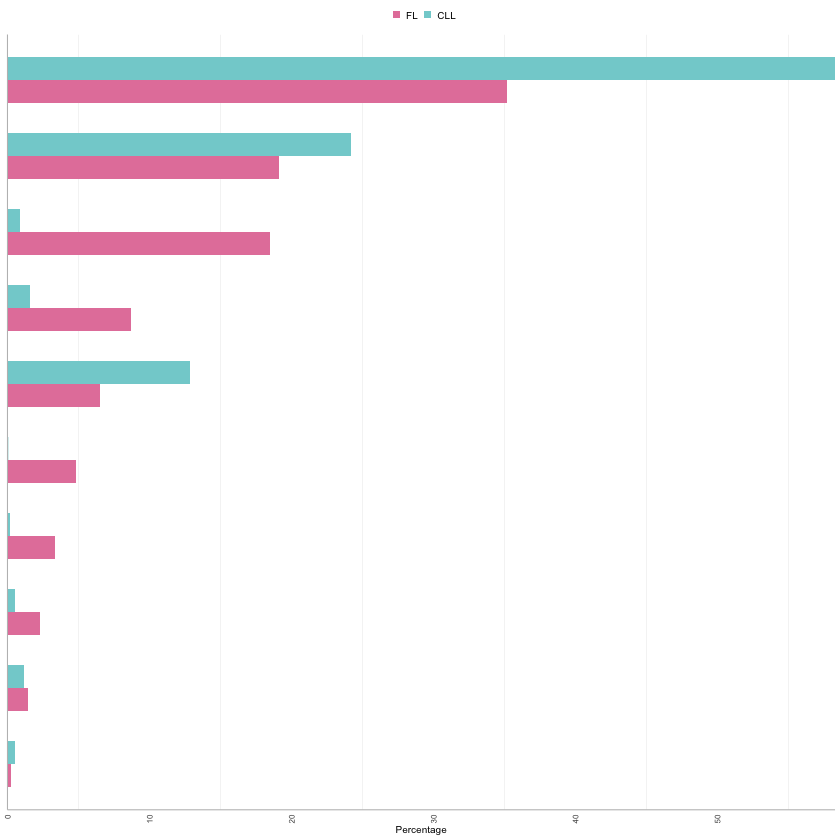

In [148]:
# create the plot
diagnosis_cluster <- ggplot(diagnosis_by_cluster, aes(x = fct_rev(factor(cluster)), y = percentage, fill = fct_rev(factor(diagnosis)))) + #aes(x = fct_rev(factor(cluster))
  geom_bar(stat = "identity", width = 0.6,position=position_dodge()) +
  scale_fill_manual(values = colors_diagnosis) +
  labs(x = "Cluster", y = "Percentage") +
  theme_minimal(base_size = 6) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
        axis.text.y = element_blank(),
        axis.title = element_text(size = 6),
        axis.title.y = element_blank(),
        legend.position = "top",
        legend.title = element_blank(),
        legend.text = element_text(size = 6),
        plot.title = element_text(size = 10, face = "bold", hjust = 0.5),
        panel.grid.major = element_blank(),
        legend.key.size = unit(0.4,"line"),
 #       panel.grid.minor = element_blank(),
        axis.line = element_line(color="grey", size = 0.3)
 #       panel.border = element_blank(),
 #       panel.background = element_blank()) 
        )+
#  coord_cartesian(clip = "off", ylim = c(0, max(100, na.rm = TRUE) * 1.1)) +
  scale_y_continuous(expand = c(0, 0.02)) +
  guides(fill = guide_legend(ncol = 2)) + coord_flip()

diagnosis_cluster

In [149]:
fig_save(diagnosis_cluster, filename = "figs_paper/diagnosis_cluster", formats = c("pdf", "png"), width = 1.81, height = 5.38, units = "cm", dpi = 320)

### **Analysis DNA repair genes**

In [86]:
# FL_merge <- readRDS("output/K12345678_SCT_merge.rds")

In [87]:
# dataset <-FL_merge

# # filter only the GEX for the list of genes
# dda <- dataset@assays$SCT@data %>%
#   as.data.frame() %>%
#   rownames_to_column(var = "gene") %>%
#   filter(gene %in% genes_names$gene) %>%
#   column_to_rownames(var = "gene") %>%
#   t() %>%
#   as.data.frame() %>%
#   rownames_to_column(var = "cell")

# head(dda)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,K1B_AAACCTGAGATCACGG-1,0.0000000,0,0.0000000,0.0000000,1.3862944,0,0,0,0.6931472,⋯,0,0,0,0,0,0.0000000,0,0,0,0
2,K1B_AAACCTGAGCCAGTTT-1,0.0000000,0,0.6931472,0.6931472,1.0986123,0,0,0,0.0000000,⋯,0,0,0,0,0,0.0000000,0,0,0,0
3,K1B_AAACCTGAGCGGCTTC-1,0.0000000,0,0.6931472,0.0000000,0.0000000,0,0,0,0.6931472,⋯,0,0,0,0,0,0.0000000,0,0,0,0
4,K1B_AAACCTGAGGCATGTG-1,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0,0.6931472,0,0,0,0
5,K1B_AAACCTGAGTGTTTGC-1,0.6931472,0,0.0000000,0.0000000,1.3862944,0,0,0,0.0000000,⋯,0,0,0,0,0,0.0000000,0,0,0,0
6,K1B_AAACCTGCAACTGCTA-1,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0,0.0000000,0,0,0,0


In [80]:
# # clean df and include experiment column
# pd <- dda %>%
#   mutate(experiment = str_sub(cell, 1, 3)) %>% 
#   mutate(cell = gsub("^.{4}|.{2}$", "", cell)) 
# head(pd)

In [81]:
# write.csv(pd, "output/expression_dna_repair_K12345678.csv",row.names = FALSE)

In [3]:
pd <- read.csv("output/expression_dna_repair_K12345678.csv")
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGATCACGG,0.0000000,0,0.0000000,0.0000000,1.3862944,0,0,0,0.6931472,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
2,AAACCTGAGCCAGTTT,0.0000000,0,0.6931472,0.6931472,1.0986123,0,0,0,0.0000000,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
3,AAACCTGAGCGGCTTC,0.0000000,0,0.6931472,0.0000000,0.0000000,0,0,0,0.6931472,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
4,AAACCTGAGGCATGTG,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0.6931472,0,0,0,0,K1B
5,AAACCTGAGTGTTTGC,0.6931472,0,0.0000000,0.0000000,1.3862944,0,0,0,0.0000000,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
6,AAACCTGCAACTGCTA,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B


In [5]:
pd

cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4,experiment
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAACCTGAGATCACGG,0.0000000,0,0.0000000,0.0000000,1.3862944,0,0.0000000,0.0000000,0.6931472,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGAGCCAGTTT,0.0000000,0,0.6931472,0.6931472,1.0986123,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGAGCGGCTTC,0.0000000,0,0.6931472,0.0000000,0.0000000,0,0.0000000,0.0000000,0.6931472,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGAGGCATGTG,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.6931472,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGAGTGTTTGC,0.6931472,0,0.0000000,0.0000000,1.3862944,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGCAACTGCTA,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGCACCACCAG,0.0000000,0,0.6931472,0.0000000,1.0986123,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGCATGCCACG,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.6931472,0.0000000,0.0000000,0.0000000,0,K1B
AAACCTGCATTTCAGG,0.6931472,0,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.0000000,⋯,0,0.0000000,0,0,0.0000000,0.0000000,0.0000000,0.0000000,0,K1B


In [9]:
table(pd$experiment) 
table(pd$experiment) %>% sum()


  K1B   K2B   K3B   K4B   K5B   K6B   K7B   K8B 
 8426  8615 11316  9425 11829 12199 16312 16493 

[1] 94615

In [10]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

ERROR: Error in mutate(., experiment = str_sub(subject, 1, 3), group = "SHMss_observed"): object 'df_summary' not found


In [ ]:
print("number of cells without ssSHM")
cell_list %>% filter(group == "SHMss_not_observed") %>% pull(cell) %>% str()

### Reference cells -> Filtering cells "SHMss_not_observed"

In [ ]:
print("Total cells scRNA experiments")
cell_list %>% pull(cell) %>% str()

#### 1. Remove doublets

In [13]:
print("Total cells doublet analysis")
doublet %>% pull(cell) %>% str()

print("Doublet cells")
doublet %>% filter(scDblFinder.class == "doublet") %>% pull(cell) %>% str()

[1] "Total cells doublet analysis"
 chr [1:94615] "AAACCTGAGATCACGG" "AAACCTGAGCCAGTTT" "AAACCTGAGCGGCTTC" ...
[1] "Doublet cells"
 chr [1:13080] "AAACCTGAGCGGCTTC" "AAACGGGCATTGGCGC" "AAAGTAGTCAACGAAA" ...


In [14]:
# Select doublet cells and generated a df for anti_join
doublet_pos <- doublet %>% filter(scDblFinder.class == "doublet") %>% 
               select(experiment,cell) %>% mutate(group = "SHMss_not_observed")

In [15]:
# remove doublet (13080 cells)

cell_list1 <- cell_list %>%
  anti_join(doublet_pos)# remove possible false positives

Joining with `by = join_by(experiment, cell, group)`


In [16]:
print("Total cells scRNA experimets AFTER filtering of doublet")
cell_list1 %>% filter(group == "SHMss_not_observed") %>% pull(cell) %>% str()

[1] "Total cells scRNA experimets AFTER filtering of doublet"
 chr [1:81171] "AAACCTGAGATCACGG" "AAACCTGAGCCAGTTT" "AAACCTGAGGCATGTG" ...


#### 2. We removed cells that could be false positive

In [17]:
print("number of cells with ssSHM")
df_summary %>% pull(cell) %>% unique() %>% str()

[1] "number of cells with ssSHM"
 chr [1:364] "AGCTTGACAATGGACG" "CTAGCCTCAATCACAC" "CGAGCACAGGTTCCTA" ...


In [18]:
# barcodes of cells with scSHM to filter the df with all the events
cells_SHM <- cell_list %>% filter(group == "SHMss_observed") %>% pull(cell)

In [19]:
# Identify false positives from BCR data

false_positives <- df %>% #all cells with events
  filter(!cell %in% cells_SHM) %>% #revove of the list of false positives the real positive cells
  mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

In [20]:
print("number of false positive cells")
false_positives %>% pull(cell) %>% str()

[1] "number of false positive cells"
 chr [1:41824] "AAACGGGCATCACGTA" "AACCGCGGTAAATGTG" "ACCAGTACATTTCAGG" ...


In [21]:
# remove possible false positives

cell_list2 <- cell_list1 %>%
#  right_join(df_complete_cells) %>% # retain cells with complete coverage of VDJ
  anti_join(false_positives)# remove possible false positives

Joining with `by = join_by(experiment, cell, group)`


In [22]:
print("Total cells scRNA experimets AFTER filtering of false positives")
cell_list2 %>% filter(group == "SHMss_not_observed") %>% pull(cell) %>% str()

[1] "Total cells scRNA experimets AFTER filtering of false positives"
 chr [1:47872] "AAACCTGAGTGTTTGC" "AAACCTGCAACTGCTA" "AAACCTGCATGCCACG" ...


#### 3. Filter cells with the same quality characteristics that scSHM (dataset: scBCR)

In [26]:
print("Total cells scBCR")
df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,cell) %>% summarize(n = n(), sum_nreads=sum(nreads)) %>% 
unique() %>% pull(cell) %>% str()

[1] "Total cells scBCR"


`summarise()` has grouped output by 'experiment'. You can override using the `.groups` argument.


 chr [1:51487] "AAACCTGAGATCACGG" "AAACCTGAGCCAGTTT" "AAACCTGAGGCATGTG" ...


In [27]:
# we take any cell with the HC o LC with the quality characteristics
quality_cells <- df_seq %>% mutate(experiment = str_sub(subject, 1, 3)) %>% group_by(experiment,subject,cell) %>% 
summarize(n = n(), sum_nreads=sum(nreads)) %>% 
filter(n >=10, sum_nreads >= 25) %>% filter(!cell %in% cells_SHM) %>% #filter cells_SHM
anti_join(doublet_pos  %>% select(experiment,cell))  %>%#filter_doublet
ungroup() %>% select(experiment, cell) %>% unique() %>% mutate(group = "SHMss_not_observed") %>%
anti_join(false_positives) #remove false positive cells

`summarise()` has grouped output by 'experiment', 'subject'. You can override using the `.groups` argument.
Joining with `by = join_by(experiment, cell)`
Joining with `by = join_by(experiment, cell, group)`


In [28]:
positive_cells <- cell_list %>% filter(group == "SHMss_observed")

In [29]:
print("number of quality negative cells")
quality_cells %>% ungroup() %>% select(experiment, cell) %>% unique() %>% str()

[1] "number of quality negative cells"
tibble [3,596 × 2] (S3: tbl_df/tbl/data.frame)
 $ experiment: chr [1:3596] "K1B" "K1B" "K1B" "K1B" ...
 $ cell      : chr [1:3596] "AAACCTGTCGGCTTGG" "ACGTCAAAGAGCCCAA" "ACGTCAACATTGAGCT" "ACTGAACCATCAGTCA" ...


In [32]:
print("Total cells scBCR experimets AFTER filtering of only quality cells")
cell_list3 %>% pull(cell) %>% str()

[1] "Total cells scBCR experimets AFTER filtering of only quality cells"
 chr [1:3960] "AAACCTGTCGGCTTGG" "ACACCAAGTCCTGCTT" "ACACTGAGTCCAGTAT" ...


In [33]:
#write.csv(cell_list3, "output/reference_cell_strict_v2.csv",row.names = FALSE)

In [34]:
# summarize data
shm_perc_sub <-  cell_list1 %>% 
  gather(-experiment, -cell, -group, key = "gene", value = "expression") %>%
  mutate(expression_cat = case_when(
     (expression > 0) & (expression < 1)  ~ ">0<1",
     (expression >= 1) & (expression <= 2)  ~ "1-2",
     (expression >2)  ~ ">2",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group) %>% filter(!is.na(group))

In [35]:
head(shm_perc_sub)

gene,group,expression_cat,count,perc,pathway
<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
ADAR,SHMss_observed,0,295,81.043956,RNSA_editing
ADAR,SHMss_observed,1-2,12,3.296703,RNSA_editing
ADAR,SHMss_observed,>0<1,57,15.659341,RNSA_editing
ADAR,SHMss_not_observed,0,65226,80.356285,RNSA_editing
ADAR,SHMss_not_observed,1-2,4235,5.217381,RNSA_editing
ADAR,SHMss_not_observed,>0<1,11708,14.423871,RNSA_editing


### DNA repair genes expression analysis

In [36]:
#define gene order for plotting
gene_order <- shm_perc_sub %>% filter(group == "SHMss_not_observed", expression_cat == "0") %>% arrange(-perc) %>% pull(gene) %>% unique()

In [37]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [38]:
# shm_perc_pub <- shm_perc_sub %>% 
#                  mutate(gene = factor(gene, levels = gene_order))  %>% 
#                  filter(!gene %in% c("ADAR")) %>% 
#                  mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
#                  mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2','>2'))) %>%
#                  mutate(diagnosis="FL") 
# #                 mutate(expression = case_when(
# #     (gene == "AICDA") & (expression == "No") ~ "F",
# #     (gene == "AICDA") & (expression == "Yes") ~ "T",
# #     TRUE ~ expression))

In [39]:
# write.csv(shm_perc_pub, "output/shm_perc_sub_k12345678_v2.csv",row.names = FALSE) 

In [ ]:
shm_perc_pub <- read.csv("output/shm_perc_sub_k12345678_v2.csv") 

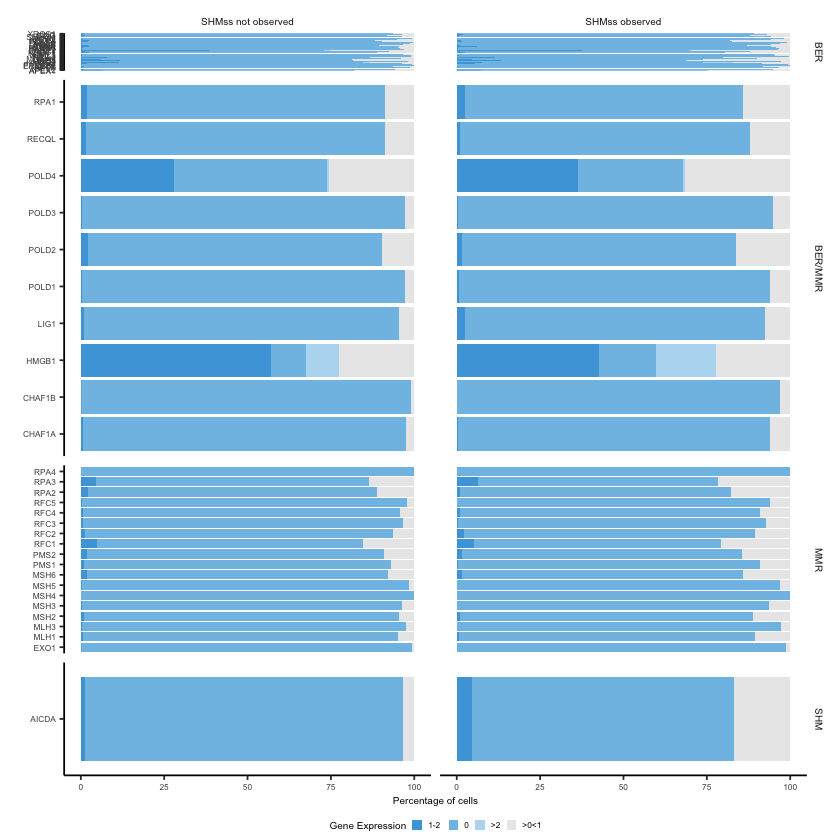

In [41]:
expre_summary <- ggplot(shm_perc_pub, aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_norm_integration", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

### Integrate CLL data

In [42]:
#shm_perc_pub <- read.csv("output/shm_perc_sub_k45678.csv")  

In [43]:
shm_perc_CLL <- read.csv("output/shm_perc_sub_CLL_norm_v1.csv") 

In [44]:
head(shm_perc_CLL)

,gene,group,expression_cat,count,perc,pathway,diagnosis
,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>
1,APEX1,SHMss_not_observed,>0<1,18,13.533835,BER,CLL
2,APEX1,SHMss_not_observed,0,115,86.466165,BER,CLL
3,APEX2,SHMss_not_observed,>0<1,3,2.255639,BER,CLL
4,APEX2,SHMss_not_observed,0,130,97.744361,BER,CLL
5,APLF,SHMss_not_observed,>0<1,2,1.503759,BER,CLL
6,APLF,SHMss_not_observed,0,131,98.496241,BER,CLL


In [45]:
#Convert that column to a factor
shm_perc_pub$group <- as.character(shm_perc_pub$group) 

**add combinations of columns (complete (function))**

In [46]:
head(shm_perc_pub)

,gene,group,expression_cat,count,perc,pathway,diagnosis
,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>
1,AICDA,SHMss_observed,0,286,78.571429,SHM,FL
2,AICDA,SHMss_observed,1-2,17,4.670330,SHM,FL
3,AICDA,SHMss_observed,>0<1,61,16.758242,SHM,FL
4,AICDA,SHMss_not_observed,0,77526,95.509480,SHM,FL
5,AICDA,SHMss_not_observed,1-2,956,1.177761,SHM,FL
6,AICDA,SHMss_not_observed,>0<1,2687,3.310296,SHM,FL


In [47]:
shm_perc_pub_int <- shm_perc_pub %>%
  bind_rows(shm_perc_CLL) %>%
    ungroup() %>%
    complete(
    diagnosis, group, nesting(gene, pathway), 
    fill = list(expression_cat = "0", count = 0, perc  = 100)
  ) %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                      mutate(group = case_when(
                    (group == "SHMss_observed") & (diagnosis == "FL")  ~ "FL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "FL")  ~ "FL scSHM \n not observed",
                    (group == "SHMss_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n not observed"
                    )) %>%
                    mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                    mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2','>2'))) %>%
                    mutate(group = factor(group, levels = c("FL scSHM \n observed","FL scSHM \n not observed", "CLL scSHM \n not observed","CLL scSHM \n observed")))

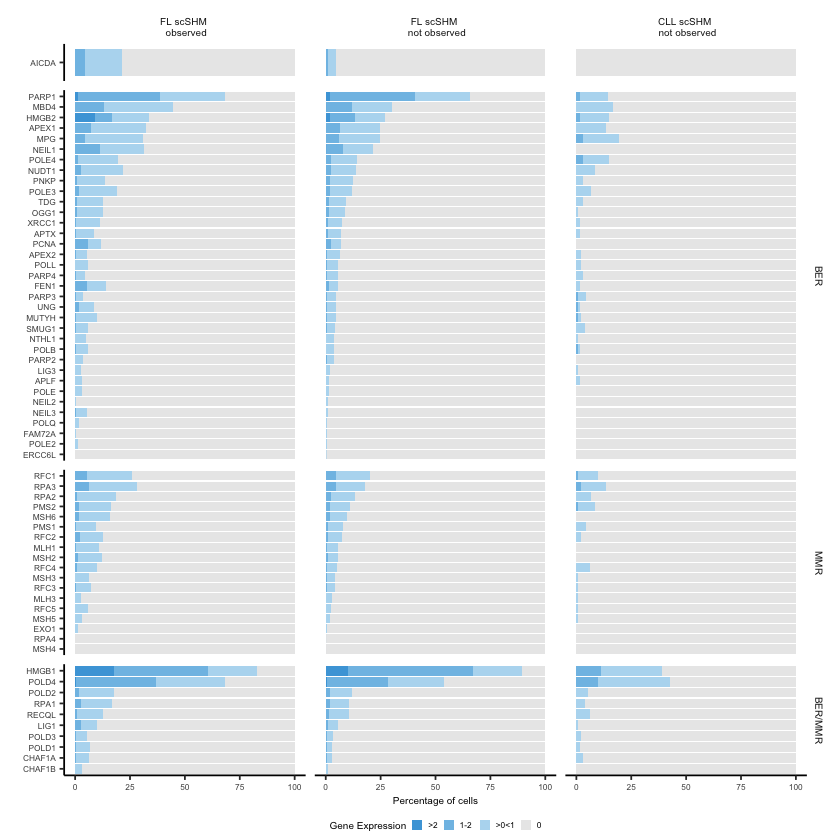

In [48]:
expre_summary <- ggplot(shm_perc_pub_int %>% filter(group != "CLL scSHM \n observed"), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
#  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free",labeller = labeller(pathway = pathway.labs )) +  # labeller = labeller(group = group.labs)
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/DNA_repair_expresion_norm_integration_wo_doublet", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

In [129]:
fig_save(expre_summary, filename = "figs/DNA_repair_expresion_norm_integration_wo_doublet", formats = c("pdf", "png"), width = 20, height = 12, units = "cm", dpi = 320)
#expre_summary

### Heatmap

In [137]:
# summarize data
shm_perc_sub <-  cell_list1 %>% 
  gather(-experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by( gene, group) %>%
  summarise(count = n(), .groups="drop_last") %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group) %>% filter(!is.na(group))

In [141]:
pr <- cell_list1 %>% 
  gather(-experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by( gene, group) %>%
  summarise(mean = mean(expression), .groups="drop_last") 

pr

gene,group,mean
<chr>,<chr>,<dbl>
ADAR,SHMss_not_observed,0.160977335
ADAR,SHMss_observed,0.146340937
AICDA,SHMss_not_observed,0.036626625
AICDA,SHMss_observed,0.170953017
APEX1,SHMss_not_observed,0.202688269
APEX1,SHMss_observed,0.257260422
APEX2,SHMss_not_observed,0.048648320
APEX2,SHMss_observed,0.039198925
APLF,SHMss_not_observed,0.011720567


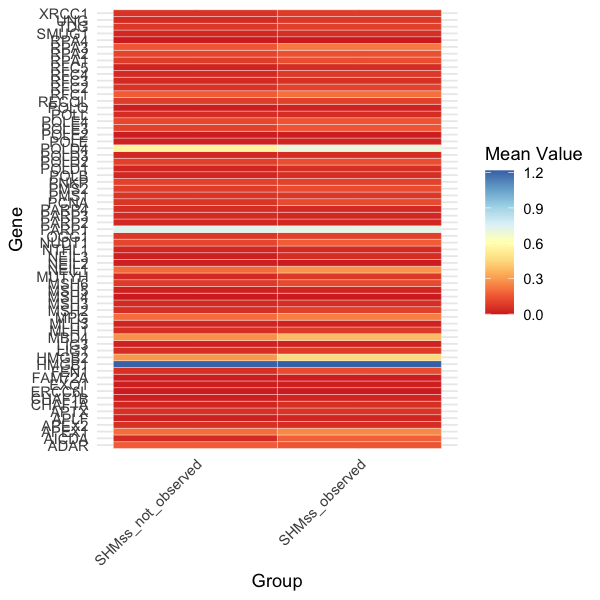

In [146]:
library(RColorBrewer)

# Create a color palette for the heatmap
#heatmap_palette <- viridis(100, option = "A", begin = 0, end = 1)
#heatmap_palette <- magma(100)
heatmap_palette <- brewer.pal(9, "RdYlBu")

# Create the heatmap using ggplot2
heatmap <- ggplot(pr, aes(x = group, y = gene, fill = mean)) +
  geom_tile(color = "white") +
  scale_fill_gradientn(colors = heatmap_palette, name = "Mean Value") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  labs(x = "Group", y = "Gene")

heatmap

# Adjust the size of the heatmap
#ggsave("heatmap.png", heatmap, width = 8, height = 10, units = "in", dpi = 300)


### AID expression

In [34]:
reference_cells_f <- read.csv("output/reference_cells_k6-8.csv") %>% dplyr::select(experiment,cell)

In [348]:
# without batch correcttion
dds <- readRDS("output/DE_k6-K8.rds")

In [355]:
normalized_counts <- counts(dds, normalized = TRUE)

In [359]:
# filter only the GEX for the list of genes
dda <- normalized_counts %>%
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dda)

,cell,RPA2,MUTYH,ADAR,PARP1,MSH2,MSH6,POLE4,PMS1,OGG1,⋯,NEIL1,MPG,NTHL1,RPA1,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CTGAAGTAGTTTAGGA-1_6,0.000000,0.3034832,0.3034832,4.552248,0.0000000,0.000000,0.000000,0.6069664,0.3034832,⋯,3.3383152,0.000000,0.0000000,0.9104496,0.6069664,0.0000000,0.000000,0.3034832,0.0000000,0.000000
2,ACTGAGTTCTACTTAC-1_6,0.000000,0.0000000,0.0000000,2.160281,0.0000000,0.000000,0.000000,0.0000000,0.0000000,⋯,0.7200938,0.000000,0.7200938,0.7200938,0.0000000,0.0000000,0.000000,0.7200938,0.0000000,0.000000
3,GACCAATTCAGCATGT-1_6,0.000000,0.5511754,2.2047015,3.307052,0.5511754,0.000000,0.000000,0.5511754,0.0000000,⋯,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.5511754,0.0000000,0.000000
4,ACGATACAGGAGCGAG-1_6,0.000000,0.3385324,0.0000000,7.447712,1.6926618,1.015597,1.015597,0.3385324,0.0000000,⋯,0.6770647,1.015597,0.3385324,1.0155971,2.3697265,0.6770647,0.000000,0.3385324,0.3385324,1.354129
5,ACTGTCCCATCTGGTA-1_6,0.827491,0.8274910,0.8274910,3.309964,0.0000000,0.000000,0.000000,0.8274910,0.0000000,⋯,3.3099641,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.827491,0.8274910,0.0000000,0.000000
6,ATCTACTGTATAGTAG-1_6,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.2842086,0.0000000,⋯,3.8526259,0.000000,0.0000000,1.2842086,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000


In [368]:
# clean df and include experiment column
pd <- dda %>%
  mutate(experiment = str_c("K", str_sub(cell, -1, -1), "B"),   # Extract last character
         cell = str_remove(cell, "-.*")) 
head(pd)

,cell,RPA2,MUTYH,ADAR,PARP1,MSH2,MSH6,POLE4,PMS1,OGG1,⋯,MPG,NTHL1,RPA1,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,CTGAAGTAGTTTAGGA,0.000000,0.3034832,0.3034832,4.552248,0.0000000,0.000000,0.000000,0.6069664,0.3034832,⋯,0.000000,0.0000000,0.9104496,0.6069664,0.0000000,0.000000,0.3034832,0.0000000,0.000000,K6B
2,ACTGAGTTCTACTTAC,0.000000,0.0000000,0.0000000,2.160281,0.0000000,0.000000,0.000000,0.0000000,0.0000000,⋯,0.000000,0.7200938,0.7200938,0.0000000,0.0000000,0.000000,0.7200938,0.0000000,0.000000,K6B
3,GACCAATTCAGCATGT,0.000000,0.5511754,2.2047015,3.307052,0.5511754,0.000000,0.000000,0.5511754,0.0000000,⋯,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.5511754,0.0000000,0.000000,K6B
4,ACGATACAGGAGCGAG,0.000000,0.3385324,0.0000000,7.447712,1.6926618,1.015597,1.015597,0.3385324,0.0000000,⋯,1.015597,0.3385324,1.0155971,2.3697265,0.6770647,0.000000,0.3385324,0.3385324,1.354129,K6B
5,ACTGTCCCATCTGGTA,0.827491,0.8274910,0.8274910,3.309964,0.0000000,0.000000,0.000000,0.8274910,0.0000000,⋯,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.827491,0.8274910,0.0000000,0.000000,K6B
6,ATCTACTGTATAGTAG,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.2842086,0.0000000,⋯,0.000000,0.0000000,1.2842086,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,K6B


In [369]:
# filter expression table only with reference cell from K6-K8
#pt <- pd %>% filter(cell %in% reference_cells_f$cell)
#write.csv(pt, "output/expressiona_DNA_repair_genes_sct_v1.csv",row.names = FALSE)
pt <- read.csv("output/expressiona_DNA_repair_genes_sct_v1.csv") 

In [370]:
# merge SHMss and expression data
merge_expression <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  filter(experiment %in% c("K6B","K7B","K8B")) %>%                                        
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pt, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [371]:
merge_expression %>% select(group, AICDA) %>%
  group_by(group) %>%
  get_summary_stats(AICDA, type = "mean_sd")

group,variable,n,mean,sd
<chr>,<fct>,<dbl>,<dbl>,<dbl>
SHMss_not_observed,AICDA,13458,0.213,0.667
SHMss_observed,AICDA,305,0.441,0.841


In [372]:
merge_expression_t <- merge_expression %>%
#  select(group, everything()) %>%
  pivot_longer(-c(experiment, cell, group), names_to = "gene", values_to = "expression") 

In [373]:
# CREATE PSEUDoBULK
meanSem<-
merge_expression_t %>% select(group, gene,expression) %>% 
group_by(group,gene) %>% 
mutate(mean=mean(expression),
sem=stderror(expression)) %>% 
ungroup() %>%
group_by(gene) %>%
mutate(pvalue = wilcox.test(expression ~ group)$p.value)  %>%
ungroup() %>%
group_by(gene) %>%
#mutate(across(contains("pvalue"), ~ p.adjust(.x, method = "fdr", n = length(.x)), .names="fdr_{.col}"))

mutate(padjusted = p.adjust(unique(pvalue), method = "BH",n=63))
# meanSem$pval<-
# round(t.test(filter(merge_expression_t,group=="SHMss_not_observed") %>% pull(expression),
# filter(merge_expression,group=="SHMss_observed") %>% pull(expression))[["p.value"]],digits = 8)

head(meanSem)

group,gene,expression,mean,sem,pvalue,padjusted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SHMss_observed,RPA2,0.0000000,0.4548985,0.03373632,4.514525e-09,2.844151e-07
SHMss_observed,MUTYH,0.3034832,0.1504048,0.02621212,3.133573e-04,1.974151e-02
SHMss_observed,ADAR,0.3034832,0.5050992,0.03843262,1.318162e-01,1.000000e+00
SHMss_observed,PARP1,4.5522480,3.5752341,0.13292245,5.877971e-01,1.000000e+00
SHMss_observed,MSH2,0.0000000,0.2224909,0.02435106,2.685787e-06,1.692046e-04
SHMss_observed,MSH6,0.0000000,0.3085885,0.03287929,1.641074e-03,1.033877e-01


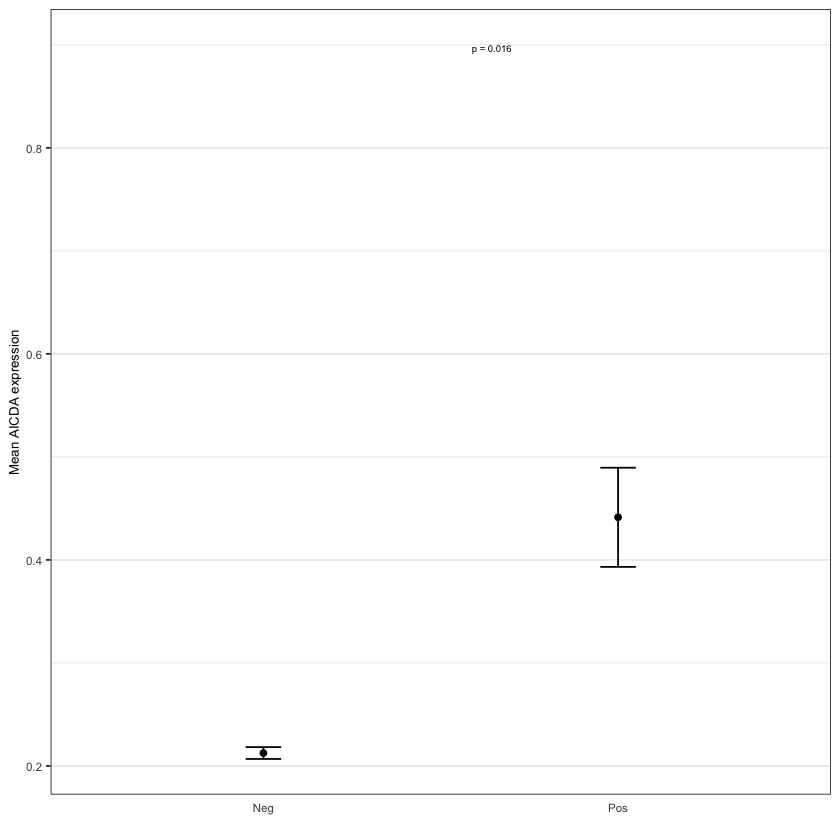

In [374]:
meanSem_aid<-
merge_expression %>% select(group, AICDA) %>% 
group_by(group) %>% 
mutate(mean=mean(AICDA),
sem=stderror(AICDA)) %>% 
ungroup()
meanSem_aid$pval<-
round(wilcox.test(filter(merge_expression,group=="SHMss_not_observed") %>% pull(AICDA),
filter(merge_expression,group=="SHMss_observed") %>% pull(AICDA))[["p.value"]],digits = 8) 

plotData<-
meanSem_aid %>% 
distinct(group,.keep_all = TRUE) %>% 
select(-AICDA)

as <- ggplot(plotData,
aes(group,mean))+
geom_point()+
ylab("Mean AICDA expression")+
geom_errorbar(aes(ymin=mean-sem, ymax=mean+sem),width=0.1)+
theme_bw()

# Add the p-value to the plot
as <- as + annotate("text", x = 1.7, y = 0.9, 
                    label = paste("p = 0.016"),
                    vjust = 1, hjust = 1, size = 2) +
theme(panel.grid.major.x = element_blank(),
panel.grid.minor.x = element_blank(),
axis.ticks.x=element_blank(),
axis.title=element_text(size=8),
axis.text=element_text(size=7)) +
scale_x_discrete(name ="",labels=c("SHMss_not_observed" = "Neg", "SHMss_observed" = "Pos"))


as

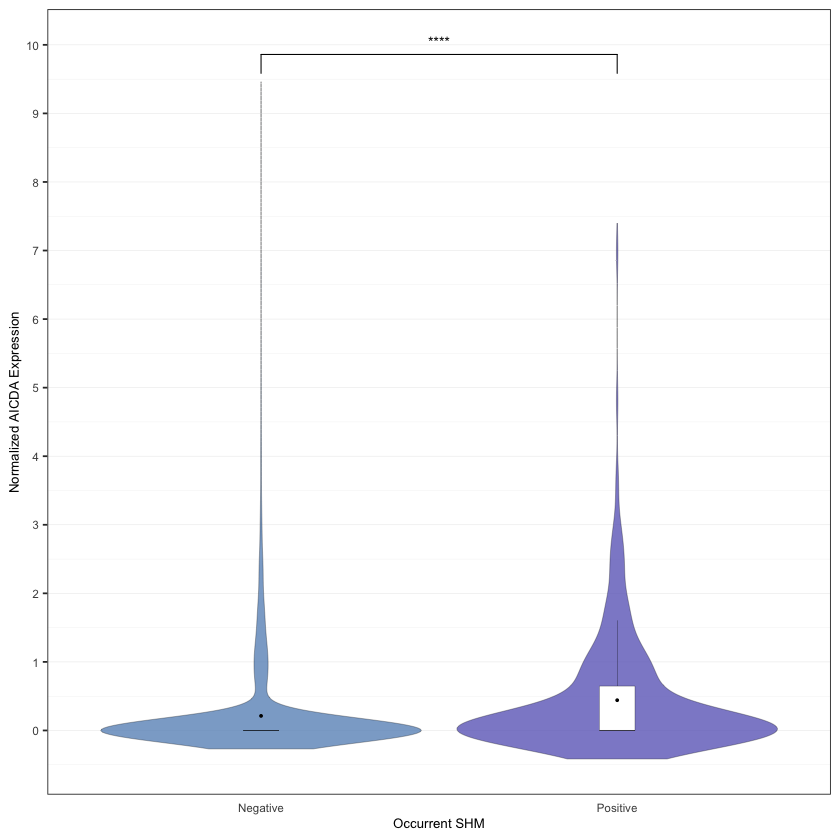

In [412]:
### Create the plot
as <- ggplot(merge_expression, aes(x = group, y = AICDA, fill = group)) + 
  # Violin plot to show the distribution of AICDA expression for each group
  geom_violin(alpha = 0.8, trim = FALSE, scale = "width", adjust =2,color = "black", size = 0.08) +
  
 # Add boxplot border for better distribution visualization
  geom_boxplot(width = 0.1, color = "black", fill = "white", size = 0.08, outlier.shape = NA) +

  # Add points for the means (we will calculate these)
  stat_summary(fun = mean, geom = "point", color = "black", size = 0.4) +  
  # Label for y-axis
  ylab("Normalized AICDA Expression") +

  # Add specific y-axis breaks (e.g., every 1 unit from 0 to 10)
  scale_y_continuous(
    breaks = seq(0, 10, by = 1)  # Adjust the range and interval here
  ) +

  # Theme adjustments
  theme_bw() +
  
  # Adjust the x-axis labels and format
  scale_x_discrete(name = "Occurrent SHM", labels = c("SHMss_not_observed" = "Negative", "SHMss_observed" = "Positive")) +
  scale_fill_manual(values = c("SHMss_not_observed" = "#6b94c2", "SHMss_observed" = "#6e6bc2")) +

  #scale_y_continuous(limits = c(NA, 5))+ # Adjust the upper limit as needed
  coord_cartesian(ylim = c(NA,10)) +

  # Add p-value using stat_compare_means
  stat_compare_means(method = "wilcox.test", label = "p.signif", label.y = 9.4,label.x = 1.5, size = 3, comparisons = list(c("SHMss_not_observed", "SHMss_observed"))) +
  
  # Customizing other aspects of the plot appearance
  theme( panel.grid.major = element_line(size = 0.15),  # Thinner major grid lines
    panel.grid.minor = element_line(size = 0.07),  # Thinner minor grid lines
            panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.x = element_blank(),  # Remove vertical minor grid lines
        axis.ticks.x = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 7), legend.position = "none")

# Display the plot
as

In [413]:
wilcox.test(AICDA ~ group, data = merge_expression)


	Wilcoxon rank sum test with continuity correction

data:  AICDA by group
W = 1625113, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [414]:
fig_save(as, filename = "figs_paper/AID_expression_2025", formats = c("pdf", "png"), width = 6, height = 7, units = "cm", dpi = 320)

#### remove outliers

In [415]:
remove_outliers <- function(df, column) {
  df %>%
    group_by(group) %>%
    mutate(
      Q1 = quantile(.data[[column]], 0.25, na.rm = TRUE),
      Q3 = quantile(.data[[column]], 0.75, na.rm = TRUE),
      IQR = Q3 - Q1,
      lower_bound = Q1 - 1.5 * IQR,
      upper_bound = Q3 + 1.5 * IQR
    ) %>%
    filter(.data[[column]] >= lower_bound & .data[[column]] <= upper_bound) %>%
    select(-Q1, -Q3, -IQR, -lower_bound, -upper_bound)
}

# Apply function to remove outliers from AICDA column
merge_expression_clean <- remove_outliers(merge_expression, "AICDA")

In [416]:
# Kolmogorov-Smirnov test (for larger samples)
ks.test(merge_expression_clean$AICDA[merge_expression_clean$group == "SHMss_not_observed"], "pnorm", mean(merge_expression_clean$AICDA), sd(merge_expression_clean$AICDA))
ks.test(merge_expression_clean$AICDA[merge_expression_clean$group == "SHMss_observed"], "pnorm", mean(merge_expression_clean$AICDA), sd(merge_expression_clean$AICDA))


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  merge_expression_clean$AICDA[merge_expression_clean$group == "SHMss_not_observed"]
D = 0.53055, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  merge_expression_clean$AICDA[merge_expression_clean$group == "SHMss_observed"]
D = 0.46945, p-value < 2.2e-16
alternative hypothesis: two-sided


In [417]:
# Wilcoxon test (for non-normal distributions)
wilcox_test_result <- wilcox.test(AICDA ~ group, data = merge_expression_clean)
print(wilcox_test_result)


	Wilcoxon rank sum test with continuity correction

data:  AICDA by group
W = 1137094, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



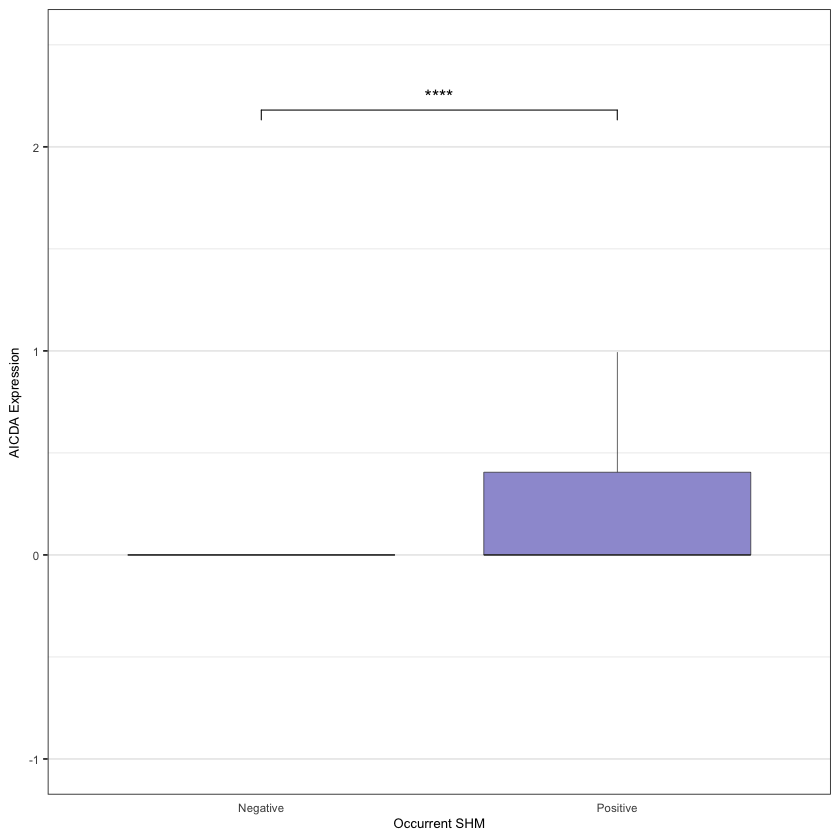

In [418]:
nw <- ggplot(merge_expression_clean, aes(x = group, y = AICDA, fill = group)) + 
  geom_boxplot(alpha = 0.7, outlier.shape = NA, size = 0.2) +  # Boxplot without jitter & outliers
  scale_fill_manual(values = c("SHMss_not_observed" = "#6b94c2", 
                               "SHMss_observed" = "#6e6bc2")) +
  theme_bw() +
  labs(x = "Group", y = "AICDA Expression") +
   coord_cartesian(ylim = c(-1, 2.5)) +
    scale_x_discrete(name = "Occurrent SHM", labels = c("SHMss_not_observed" = "Negative", "SHMss_observed" = "Positive")) +
  stat_compare_means(method = "wilcox.test", label = "p.signif", comparisons = list(c("SHMss_not_observed", "SHMss_observed")), label.y = 2.1) + # Wilcoxon test for p-value
    # Customizing other aspects of the plot appearance
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 7), legend.position = "none")

nw

In [419]:
fig_save(nw, filename = "figs_paper/AID_expression_2025_boxplot", formats = c("pdf", "png"), width = 6, height = 7, units = "cm", dpi = 320)

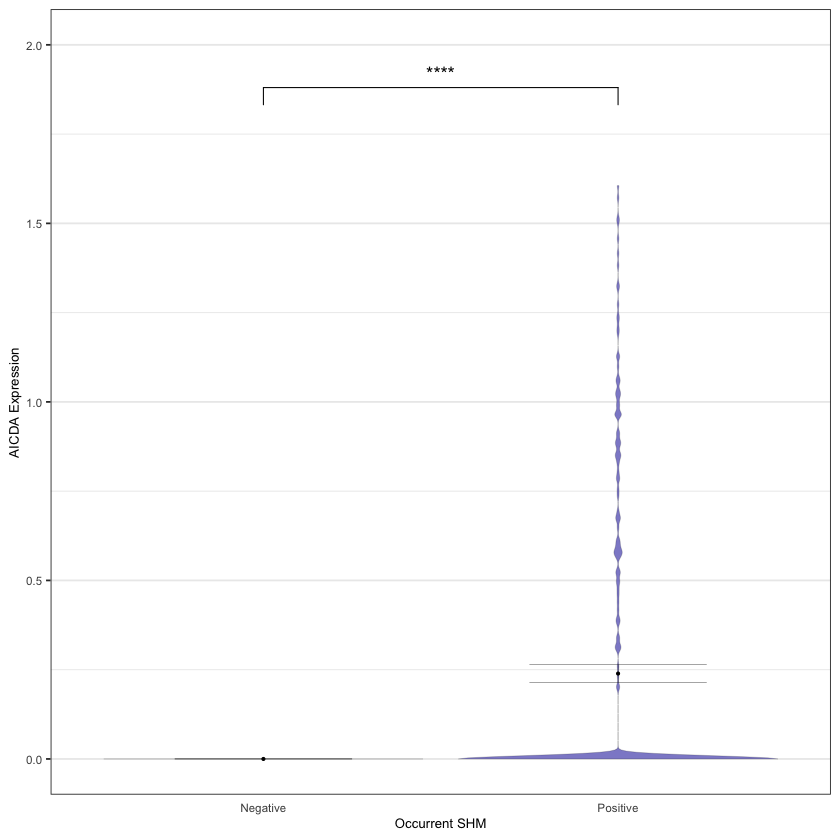

In [421]:
### Create the plot
as <- ggplot(merge_expression_clean, aes(x = group, y = AICDA, fill = group)) + 
  # Violin plot to show the distribution of AICDA expression for each group
  geom_violin(alpha = 0.8, trim = TRUE, scale = "width", adjust =0.1, color = "black", size = 0.05) +
  
  # Add points for the means (we will calculate these)
  stat_summary(fun = mean, geom = "point", color = "black", size = 0.5) +
  
  # Add error bars (we will calculate the SEM)
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.5, color = "black", size=0.1) +
  
  # Label for y-axis
  ylab("AICDA Expression") +
  
  # Theme adjustments
  theme_bw() +
  
  # Adjust the x-axis labels and format
  scale_x_discrete(name = "Occurrent SHM", labels = c("SHMss_not_observed" = "Negative", "SHMss_observed" = "Positive")) +
  scale_fill_manual(values = c("SHMss_not_observed" = "#6b94c2", "SHMss_observed" = "#6e6bc2")) +

  #scale_y_continuous(limits = c(NA, 5))+ # Adjust the upper limit as needed
  coord_cartesian(ylim = c(NA, 2)) +

  # Add p-value using stat_compare_means
  stat_compare_means(method = "wilcox.test", label = "p.signif", label.y = 1.8,label.x = 1.5,  comparisons = list(c("SHMss_not_observed", "SHMss_observed"))) +
  
  # Customizing other aspects of the plot appearance
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 7), legend.position = "none")

# Display the plot
as

In [422]:
fig_save(as, filename = "figs_paper/AID_expression_2025_nooutlier", formats = c("pdf", "png"), width = 6, height = 7, units = "cm", dpi = 320)

#### Cells positives to AID

In [ ]:
merge_expression %>% select(group, AICDA)

### ADAR expression

In [423]:
merge_expression %>% select(group, ADAR) %>%
  group_by(group) %>%
  get_summary_stats(ADAR, type = "mean_sd")

group,variable,n,mean,sd
<chr>,<fct>,<dbl>,<dbl>,<dbl>
SHMss_not_observed,ADAR,13458,0.593,0.984
SHMss_observed,ADAR,305,0.505,0.671


In [424]:
wilcox.test(ADAR ~ group, data = merge_expression)


	Wilcoxon rank sum test with continuity correction

data:  ADAR by group
W = 1962630, p-value = 0.1318
alternative hypothesis: true location shift is not equal to 0


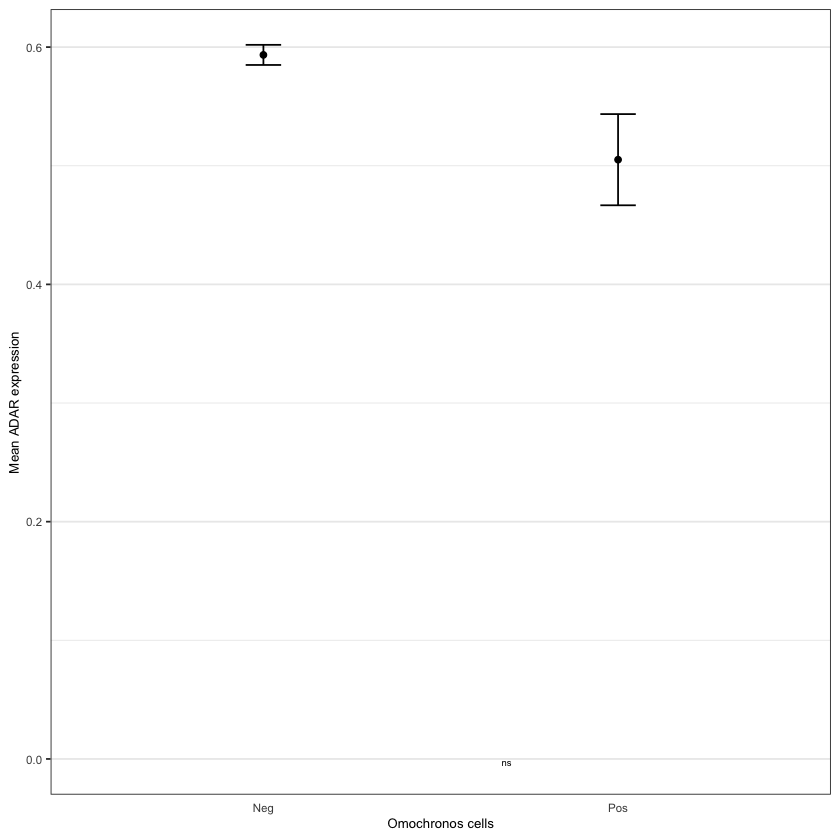

In [425]:
meanSem_aid<-
merge_expression %>% select(group, ADAR) %>% 
group_by(group) %>% 
mutate(mean=mean(ADAR),
sem=stderror(ADAR)) %>% 
ungroup()
meanSem_aid$pval<-
round(wilcox.test(filter(merge_expression,group=="SHMss_not_observed") %>% pull(ADAR),
filter(merge_expression,group=="SHMss_observed") %>% pull(ADAR))[["p.value"]],digits = 8) 

plotData<-
meanSem_aid %>% 
distinct(group,.keep_all = TRUE) %>% 
select(-ADAR)

as <- ggplot(plotData,
aes(group,mean))+
geom_point()+
ylab("Mean ADAR expression")+
geom_errorbar(aes(ymin=mean-sem, ymax=mean+sem),width=0.1)+
theme_bw()

# Add the p-value to the plot
as <- as + annotate("text", x = 1.7, y = 0, 
                    label = paste("ns"),
                    vjust = 1, hjust = 1, size = 2) +
theme(panel.grid.major.x = element_blank(),
panel.grid.minor.x = element_blank(),
axis.ticks.x=element_blank(),
axis.title=element_text(size=8),
axis.text=element_text(size=7)) +
scale_x_discrete(name ="Omochronos cells",labels=c("SHMss_not_observed" = "Neg", "SHMss_observed" = "Pos"))


as

In [426]:
fig_save(as, filename = "figs_paper/ADAR_expression", formats = c("pdf", "png"), width = 6, height = 7, units = "cm", dpi = 320)

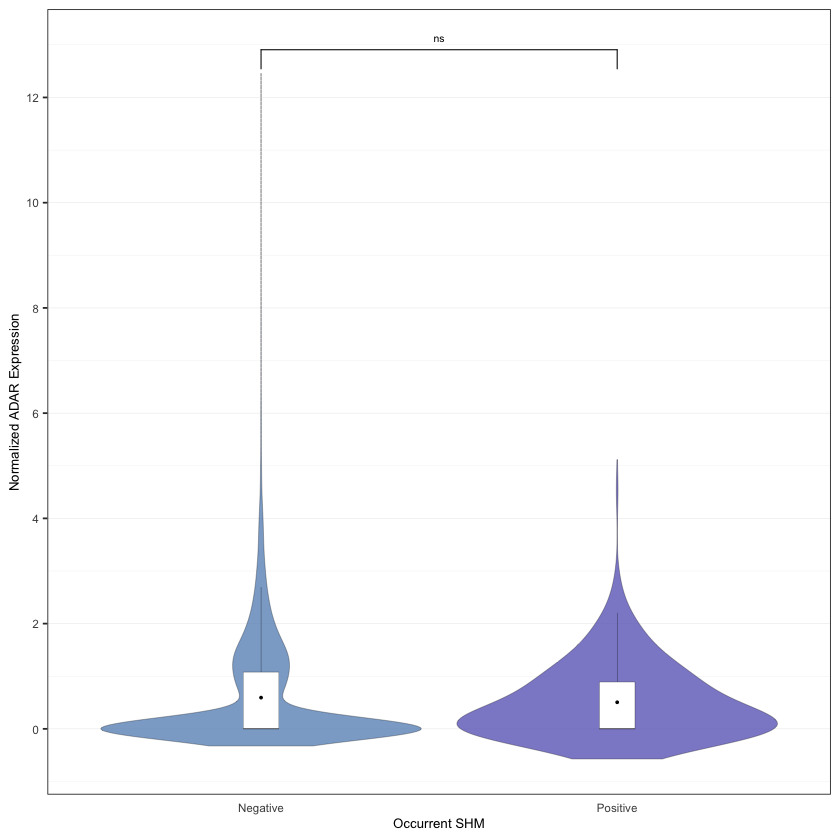

In [438]:
### Create the plot
as <- ggplot(merge_expression, aes(x = group, y = ADAR, fill = group)) + 
  # Violin plot to show the distribution of AICDA expression for each group
  geom_violin(alpha = 0.8, trim = FALSE, scale = "width", adjust =2,color = "black", size = 0.08) +
  
 # Add boxplot border for better distribution visualization
  geom_boxplot(width = 0.1, color = "black", fill = "white", size = 0.08, outlier.shape = NA) +

  # Add points for the means (we will calculate these)
  stat_summary(fun = mean, geom = "point", color = "black", size = 0.4) +  
  # Label for y-axis
  ylab("Normalized ADAR Expression") +

  # Add specific y-axis breaks (e.g., every 1 unit from 0 to 10)
  scale_y_continuous(
    breaks = seq(0, 13, by = 2)  # Adjust the range and interval here
  ) +

  # Theme adjustments
  theme_bw() +
  
  # Adjust the x-axis labels and format
  scale_x_discrete(name = "Occurrent SHM", labels = c("SHMss_not_observed" = "Negative", "SHMss_observed" = "Positive")) +
  scale_fill_manual(values = c("SHMss_not_observed" = "#6b94c2", "SHMss_observed" = "#6e6bc2")) +

  #scale_y_continuous(limits = c(NA, 5))+ # Adjust the upper limit as needed
  coord_cartesian(ylim = c(NA,13)) +

  # Add p-value using stat_compare_means
  stat_compare_means(method = "wilcox.test", label = "p.signif", label.y = 12.3,label.x = 1.5, size = 2.2, comparisons = list(c("SHMss_not_observed", "SHMss_observed"))) +
  
  # Customizing other aspects of the plot appearance
  theme( panel.grid.major = element_line(size = 0.15),  # Thinner major grid lines
    panel.grid.minor = element_line(size = 0.07),  # Thinner minor grid lines
            panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.x = element_blank(),  # Remove vertical minor grid lines
        axis.ticks.x = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 7), legend.position = "none")

# Display the plot
as

In [439]:
fig_save(as, filename = "figs_paper/ADAR_expression_2025", formats = c("pdf", "png"), width = 6, height = 7, units = "cm", dpi = 320)

### DZ/LZ genes

In [3]:
FL_merge <- readRDS("output/K12345678_SCT_merge.rds")

In [440]:
dark_light <- read.csv("input/dark_light_zone_genes.csv")

In [442]:
head(dark_light)

,gene,vict,milp,mich,trip,dz,lz,agree,score,enrichedIn,set
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<lgl>,<int>,<chr>,<chr>
1,EBI3,LZ,LZ,,,0,2,TRUE,2,LZ,vict
2,BCl2A1,LZ,,,,0,1,TRUE,1,LZ,vict
3,EGR3,LZ,LZ,LZ,,0,3,TRUE,3,LZ,vict
4,PRDM1,LZ,LZ,,,0,2,TRUE,2,LZ,vict
5,IL4I1,LZ,LZ,,,0,2,TRUE,2,LZ,vict
6,DUSP2,LZ,LZ,,,0,2,TRUE,2,LZ,vict


In [443]:
dl_genes <- dark_light %>% filter(agree == "TRUE", score>1) #filter(enrichedIn == "LZ"| enrichedIn == "DZ") #select(
head(dl_genes)

,gene,vict,milp,mich,trip,dz,lz,agree,score,enrichedIn,set
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<lgl>,<int>,<chr>,<chr>
1,EBI3,LZ,LZ,,,0,2,TRUE,2,LZ,vict
2,EGR3,LZ,LZ,LZ,,0,3,TRUE,3,LZ,vict
3,PRDM1,LZ,LZ,,,0,2,TRUE,2,LZ,vict
4,IL4I1,LZ,LZ,,,0,2,TRUE,2,LZ,vict
5,DUSP2,LZ,LZ,,,0,2,TRUE,2,LZ,vict
6,EGR2,LZ,LZ,,,0,2,TRUE,2,LZ,vict


In [19]:
de_results <- results(dds_high) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

In [30]:
de_dl_genes <- de_results %>% filter(padj <= 0.05, rowname %in% dl_genes$gene) #129 genes

In [32]:
# filter only the GEX for the list of genes
dda <- FL_merge$SCT@scale.data %>%
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% de_dl_genes$rowname) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dda)

,cell,SRM,ZC3H12A,CDCA8,CDC20,KIF2C,FCRL5,SLAMF1,NUF2,IER5,⋯,CALR,IER2,IFI30,VASP,IL4I1,UBE2S,CYTH4,GTSE1,SAMSN1,ITGB2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,K1B_AAACCTGAGATCACGG-1,-0.2261935,-0.2373479,-0.1593014,-0.1683642,-0.08736815,-0.2202732,-0.3966545,-0.1383778,-0.2193597,⋯,-0.7775472,1.1607705,3.2015735,-0.3921608,-0.1646996,-0.2811247,-0.2661184,-0.1183966,1.6413075,-0.2998885
2,K1B_AAACCTGAGCCAGTTT-1,-0.3000117,-0.3097991,-0.2126201,-0.2231978,-0.12587554,-0.2876878,-0.4985608,-0.1868296,-0.2865653,⋯,1.7043211,-0.8061969,2.2059917,-0.5046437,-0.2149238,-0.3640424,-0.3416501,-0.1622868,-0.6046489,-0.3846797
3,K1B_AAACCTGAGCGGCTTC-1,-0.3072818,-0.3169349,-0.2178841,-0.2286088,-0.12970105,-0.2943285,-0.5085550,-0.1916223,-0.2931855,⋯,-0.9851816,-0.8204910,-0.3884811,-0.5156425,-0.2198880,-0.3722039,-0.3490886,-0.1666380,-0.6173342,-0.3930238
4,K1B_AAACCTGAGGCATGTG-1,-0.2204498,-0.2317107,-0.1551620,-0.1641053,-0.08439982,-0.2150286,-0.3886938,-0.1346239,-0.2141313,⋯,-0.7620855,1.2236033,-0.2908286,-0.3833506,-0.1608051,-0.2746693,-0.2602411,-0.1150046,-0.4638510,-0.2932858
5,K1B_AAACCTGAGTGTTTGC-1,-0.2017367,-0.2133450,-0.1416846,-0.1502365,-0.07475990,-0.1979420,2.7792847,-0.1224094,4.6765368,⋯,-0.7110990,5.5546605,-0.2697674,-0.3545928,-0.1481298,-0.2536338,-0.2410922,-0.1039777,-0.4302678,-0.2717691
6,K1B_AAACCTGCAACTGCTA-1,-0.2132043,-0.2245997,-0.1499421,-0.1587342,-0.08066167,-0.2084127,-0.3786454,-0.1298917,-0.2075360,⋯,0.6039517,-0.6313355,-0.2826747,-0.3722257,-0.1558950,-0.2665252,-0.2528269,-0.1107307,-0.4508669,-0.2849557


In [33]:
# clean df and include experiment column
pd <- dda %>%
  mutate(experiment = str_sub(cell, 1, 3)) %>% 
  mutate(cell = gsub("^.{4}|.{2}$", "", cell)) 
head(pd)

,cell,SRM,ZC3H12A,CDCA8,CDC20,KIF2C,FCRL5,SLAMF1,NUF2,IER5,⋯,IER2,IFI30,VASP,IL4I1,UBE2S,CYTH4,GTSE1,SAMSN1,ITGB2,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGATCACGG,-0.2261935,-0.2373479,-0.1593014,-0.1683642,-0.08736815,-0.2202732,-0.3966545,-0.1383778,-0.2193597,⋯,1.1607705,3.2015735,-0.3921608,-0.1646996,-0.2811247,-0.2661184,-0.1183966,1.6413075,-0.2998885,K1B
2,AAACCTGAGCCAGTTT,-0.3000117,-0.3097991,-0.2126201,-0.2231978,-0.12587554,-0.2876878,-0.4985608,-0.1868296,-0.2865653,⋯,-0.8061969,2.2059917,-0.5046437,-0.2149238,-0.3640424,-0.3416501,-0.1622868,-0.6046489,-0.3846797,K1B
3,AAACCTGAGCGGCTTC,-0.3072818,-0.3169349,-0.2178841,-0.2286088,-0.12970105,-0.2943285,-0.5085550,-0.1916223,-0.2931855,⋯,-0.8204910,-0.3884811,-0.5156425,-0.2198880,-0.3722039,-0.3490886,-0.1666380,-0.6173342,-0.3930238,K1B
4,AAACCTGAGGCATGTG,-0.2204498,-0.2317107,-0.1551620,-0.1641053,-0.08439982,-0.2150286,-0.3886938,-0.1346239,-0.2141313,⋯,1.2236033,-0.2908286,-0.3833506,-0.1608051,-0.2746693,-0.2602411,-0.1150046,-0.4638510,-0.2932858,K1B
5,AAACCTGAGTGTTTGC,-0.2017367,-0.2133450,-0.1416846,-0.1502365,-0.07475990,-0.1979420,2.7792847,-0.1224094,4.6765368,⋯,5.5546605,-0.2697674,-0.3545928,-0.1481298,-0.2536338,-0.2410922,-0.1039777,-0.4302678,-0.2717691,K1B
6,AAACCTGCAACTGCTA,-0.2132043,-0.2245997,-0.1499421,-0.1587342,-0.08066167,-0.2084127,-0.3786454,-0.1298917,-0.2075360,⋯,-0.6313355,-0.2826747,-0.3722257,-0.1558950,-0.2665252,-0.2528269,-0.1107307,-0.4508669,-0.2849557,K1B


In [34]:
cell_list3 <- read.csv("output/reference_cell_strict_v2.csv")#write.csv(cell_list3, "output/reference_cell_strict_v2.csv",row.names = FALSE)

In [35]:
# pt <- pd %>% filter(cell %in% cell_list3$cell)
# write.csv(pt, "output/expression_dark_light_genes_sct.csv",row.names=FALSE)
pt <- read.csv("output/expression_dark_light_genes_sct.csv") 

In [38]:
# merge SHMss and expression data
merge_expression <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pt, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [40]:
head(merge_expression)

,experiment,cell,group,SRM,ZC3H12A,CDCA8,CDC20,KIF2C,FCRL5,SLAMF1,⋯,CALR,IER2,IFI30,VASP,IL4I1,UBE2S,CYTH4,GTSE1,SAMSN1,ITGB2
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,K1B,AGCTTGACAATGGACG,SHMss_observed,-0.2640035,-0.2744571,-0.1865828,-0.1964266,-0.10701228,-0.2548006,-0.4489470,⋯,-0.8769419,-0.7345529,-0.3398254,1.6765778,-0.1903843,2.6548681,-0.3048071,-0.1408102,3.0410458,-0.3433345
2,K1B,CTAGCCTCAATCACAC,SHMss_observed,-0.2230588,-0.2342714,-0.1570421,-0.1660398,-0.08574763,-0.2174109,-0.3923105,⋯,0.5096946,-0.6515346,-0.2937646,-0.3873536,-0.1625739,-0.2776017,-0.2629108,-0.1165450,-0.4685205,-0.2962851
3,K1B,CGAGCACAGGTTCCTA,SHMss_observed,-0.4072941,3.7133892,-0.2905622,-0.3032718,-0.18283058,1.8348393,-0.6452056,⋯,-0.6351483,-1.0105051,1.2944564,-0.6653308,-0.2885234,-0.4843841,-0.4514065,-0.2269833,0.2718256,-0.5076783
4,K1B,ATCATGGGTGGTCTCG,SHMss_observed,-0.2540525,-0.2646905,-0.1793972,-0.1890365,-0.10182536,-0.2457131,-0.4352036,⋯,0.2459577,0.8859197,-0.3286336,-0.4347782,-0.1836164,-0.3124283,-0.2946251,-0.1348974,-0.5237339,-0.3319034
5,K1B,TCTTTCCGTCTAGTCA,SHMss_observed,-0.2696692,-0.2800179,-0.1906759,-0.2006358,-0.10997071,-0.2599749,-0.4567658,⋯,0.1284489,0.7498724,-0.3461968,-0.4585815,-0.1942403,-0.3299704,-0.3106043,-0.1441811,1.1982439,-0.3498419
6,K1B,ACGCCAGAGGCATTGG,SHMss_observed,-0.2423269,-0.2531821,-0.1709352,-0.1803326,-0.09572863,-0.2350054,4.7903186,⋯,1.5014906,-0.6907925,-0.3154437,1.9128449,-0.1756490,-0.2992544,3.3085261,-0.1279427,-0.5029027,-0.3184307


In [59]:
stderror <- function(x) sd(x)/sqrt(length(x))
                                   
merge_expression_t <- merge_expression %>%
  pivot_longer(-c(experiment, cell, group), names_to = "gene", values_to = "expression") 

meanSem<-
merge_expression_t %>% select(group, gene,expression) %>% 
group_by(group,gene) %>% 
mutate(mean=mean(expression),
sem=stderror(expression)) %>% 
ungroup() %>%
group_by(gene) %>%
mutate(pvalue = wilcox.test(expression ~ group)$p.value)  %>%
ungroup() %>%
group_by(gene) %>%
mutate(padjusted = p.adjust(unique(pvalue), method = "BH",n=63)) %>%
left_join(dl_genes %>% select(gene,enrichedIn,set), by = c("gene")) %>%
select(-expression,-sem) %>% unique()


head(meanSem)

group,gene,mean,pvalue,padjusted,enrichedIn,set
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
SHMss_observed,SRM,-0.0137066301,1.909612e-42,1.203056e-40,LZ,vict
SHMss_observed,ZC3H12A,0.0002252738,4.545084e-93,2.863403e-91,LZ,vict
SHMss_observed,CDCA8,0.3327230599,1.543141e-09,9.721788e-08,DZ,vict
SHMss_observed,CDC20,0.4121954227,3.588136e-15,2.260525e-13,DZ,vict
SHMss_observed,KIF2C,0.1755828507,4.166878e-34,2.625133e-32,DZ,vict
SHMss_observed,FCRL5,0.0435955705,2.133683e-01,1.000000e+00,LZ,milp


In [74]:
NLigColors<-
  c("#D55E00","#F0E442") %>% setNames(c("SHMss_observed","SHMss_not_observed"))

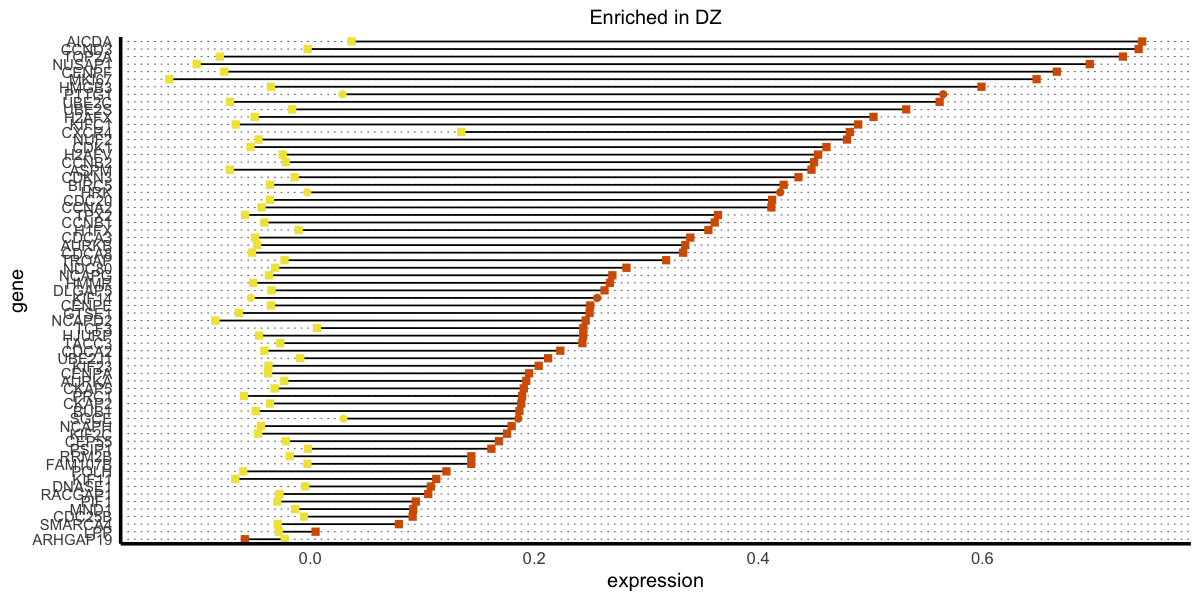

In [204]:
plotDataDZ<-
  filter(meanSem,enrichedIn=="DZ")

plotdataDZplotSupport<-
  select(plotDataDZ,-enrichedIn) %>% 
  pivot_wider(names_from = group,values_from = mean) %>% 
  mutate(match=sign(SHMss_observed-SHMss_not_observed)==1)

# factor genes by expr
plotDataDZ$gene<-
  factor(plotDataDZ$gene,
         levels=c(plotdataDZplotSupport %>% filter(match==FALSE) %>% arrange(desc(SHMss_not_observed)) %>% pull(gene),
                  plotdataDZplotSupport %>% filter(match==TRUE) %>% arrange(SHMss_observed) %>% pull(gene)))

# factor shape
plotDataDZ$set<-
  factor(plotDataDZ$set,levels = c("vict","milp","mich","trip"))

shapeSet<-
  c(15,16,17,18) %>%
  setNames(levels(plotDataDZ$set))

p1<-
  ggplot(plotDataDZ,
         aes(gene,mean,color=group,shape=set))+
  geom_line(aes(group=gene),color="black")+  
  geom_point(size=2)+
  scale_color_manual(values=NLigColors)+
  scale_shape_manual(values=shapeSet)+
  coord_flip()+
  ggtitle("Enriched in DZ")+
  theme(axis.title.y = element_blank())+
  theme_bw()+
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.ticks=element_blank(),
        axis.title=element_text(size=12),
        axis.text.y=element_text(size=9),
        axis.text.x=element_text(size=10),
        legend.position="none",
        plot.title = element_text(size=12,hjust=0.5),
        panel.grid.minor=element_blank(),
        panel.background=element_blank(),
        panel.grid.major.y=element_line(colour="black",linetype = 3,linewidth = 0.2),        
        panel.border=element_blank(),#rect(colour="black",fill=NA,size=1))
        axis.line = element_line(size=1,color="black")) +
     ylab("expression") 

p1

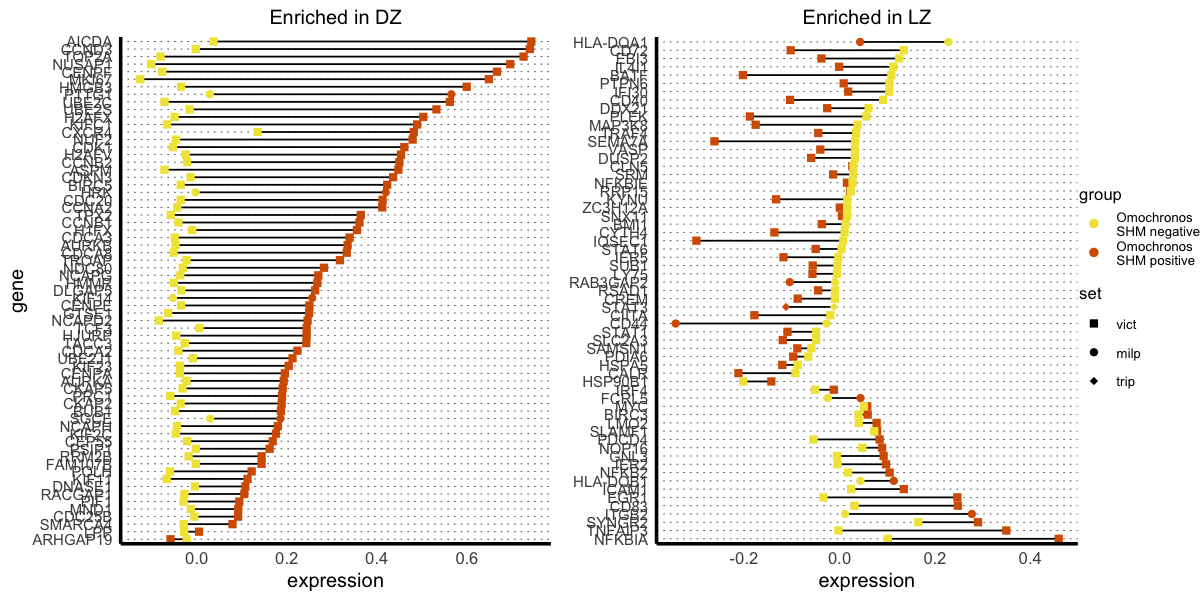

In [210]:
plotDataLZ<-
  filter(meanSem,enrichedIn=="LZ")

plotdataLZplotSupport<-
  select(plotDataLZ,-enrichedIn) %>% 
  pivot_wider(names_from = group,values_from = mean) %>% 
  mutate(match=sign(SHMss_observed-SHMss_not_observed)==1)

# factor genes by expr
plotDataLZ$gene<-
  factor(plotDataLZ$gene,
         levels=c(plotdataLZplotSupport %>% filter(match==TRUE) %>% arrange(desc(SHMss_observed)) %>% pull(gene),
                  plotdataLZplotSupport %>% filter(match==FALSE) %>% arrange(SHMss_not_observed) %>% pull(gene)))

# factor shape
plotDataLZ$set<-
  factor(plotDataLZ$set,levels = c("vict","milp","mich","trip"))

shapeSet<-
  c(15,16,17,18) %>%
  setNames(levels(plotDataLZ$set))

#scale_x_discrete(labels = c("SHMa_observed"="Omochronos SHM positive", "SHMa_not_observed" = "Omochronos SHM negative")) +

p2<-
  ggplot(plotDataLZ,
         aes(gene,mean,color=group,shape=set))+
  geom_line(aes(group=gene),color="black")+
  geom_point(size=2)+
  scale_color_manual(values=NLigColors,labels = c("SHM ongoing negative","SHM ongoing positive"))+
  scale_shape_manual(values=shapeSet)+
  coord_flip()+
  ggtitle("Enriched in LZ")+
  labs(fill ="average gene expression") +
  theme(axis.title.y = element_blank())+
  theme_bw()+
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.ticks=element_blank(),
        axis.title.x=element_text(size=12),
        axis.title.y=element_blank(),
        axis.text.y=element_text(size=9),
        axis.text.x=element_text(size=10),
        legend.text=element_text(size=8),
        legend.title=element_text(size=10),
        panel.grid.minor=element_blank(),
        panel.background=element_blank(),
        plot.title = element_text(size=12,hjust=0.5),
        panel.grid.major.y=element_line(colour="black",linetype = 3,linewidth = 0.2),
        panel.border=element_blank(),#rect(colour="black",fill=NA,size=1))
        axis.line = element_line(size=1,color="black"),
           legend.margin=margin(0,0,0,0),
    legend.box.margin=margin(-10,-5.5,-10,-10)) +
  ylab("expression") 


td <- gridExtra::grid.arrange(p1,p2,nrow=1,widths=c(0.7,0.8))


In [211]:
fig_save(td, filename = "figs_paper/dark_light_genes", formats = c("pdf", "png"), width = 17, height = 18, units = "cm", dpi = 320)